<a href="https://colab.research.google.com/github/saraocosta31/Sara/blob/main/PF_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Carteira de Reforma

Backtest histórico, Capital Market Expectations e Simulação de Monte Carlo.

## 1. Configurações Gerais

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
from pandas_datareader import data as pdr
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

START_DATE = "2008-01-01"
END_DATE   = "2026-06-01"

tickers = {
    "Acoes_EUA":    "SPY",
    "Acoes_Europa": "IMEU.AS",
    "Emergentes":   "EEM",
    "Obrigacoes":   "AGG",
    "Ouro":         "GLD",
    "EURUSD":       "EURUSD=X"
}

## 2. Pesos das Carteiras

In [2]:
weights = pd.DataFrame({
    "Fase_1": {
        "Acoes_EUA":    0.40,
        "Acoes_Europa": 0.25,
        "Emergentes":   0.10,
        "Obrigacoes":   0.20,
        "Ouro":         0.05,
        "Liquidez":     0.00
    },
    "Fase_2": {
        "Acoes_EUA":    0.30,
        "Acoes_Europa": 0.25,
        "Emergentes":   0.05,
        "Obrigacoes":   0.35,
        "Ouro":         0.05,
        "Liquidez":     0.00
    },
    "Fase_3": {
        "Acoes_EUA":    0.15,
        "Acoes_Europa": 0.10,
        "Emergentes":   0.00,
        "Obrigacoes":   0.60,
        "Ouro":         0.10,
        "Liquidez":     0.05
    }
})

print("Soma dos pesos por carteira:")
print(weights.sum())

Soma dos pesos por carteira:
Fase_1    1.0
Fase_2    1.0
Fase_3    1.0
dtype: float64


## 3. Download dos Preços via Yahoo Finance

In [3]:
def download_prices(tickers_dict, start, end):
    symbols = list(tickers_dict.values())
    data = yf.download(symbols, start=start, end=end,
                       auto_adjust=True, progress=False)
    if isinstance(data.columns, pd.MultiIndex):
        prices = data["Close"].copy()
    else:
        prices = data[["Close"]].copy()
    reverse_map = {v: k for k, v in tickers_dict.items()}
    prices = prices.rename(columns=reverse_map)
    monthly_prices = prices.resample("ME").last()
    usd_assets = ["Acoes_EUA", "Emergentes", "Obrigacoes", "Ouro"]
    for asset in usd_assets:
        monthly_prices[asset] = monthly_prices[asset] / monthly_prices["EURUSD"]
    monthly_prices = monthly_prices.drop(columns=["EURUSD"])
    return monthly_prices

prices = download_prices(tickers, START_DATE, END_DATE)
print("Preços mensais descarregados:")
print(prices.tail())
print("\nPrimeira data disponível por ativo:")
print(prices.apply(lambda x: x.first_valid_index()))

Preços mensais descarregados:
Ticker      Obrigacoes  Emergentes        Ouro  Acoes_Europa   Acoes_EUA
Date                                                                    
2026-01-31   82.314907   49.135655  371.853623     37.357494  575.236214
2026-02-28   84.783197   52.746120  409.852352     38.869514  578.125831
2026-03-31   85.753966   49.298714  375.471085     35.867760  566.028505
2026-04-30   84.246882   54.480746  362.576698     37.761784  613.463142
2026-05-31   84.725280   58.565370  357.955715     38.965000  647.512763

Primeira data disponível por ativo:
Ticker
Obrigacoes     2008-01-31
Emergentes     2008-01-31
Ouro           2008-01-31
Acoes_Europa   2008-01-31
Acoes_EUA      2008-01-31
dtype: datetime64[ns]


## 4. Retornos Mensais dos Ativos

In [4]:
asset_returns_market = prices.pct_change()
print("Retornos mensais dos ativos de mercado:")
print(asset_returns_market.tail())

Retornos mensais dos ativos de mercado:
Ticker      Obrigacoes  Emergentes      Ouro  Acoes_Europa  Acoes_EUA
Date                                                                 
2026-01-31   -0.015798    0.060521  0.102236      0.030621  -0.003787
2026-02-28    0.029986    0.073480  0.102187      0.040474   0.005023
2026-03-31    0.011450   -0.065358 -0.083887     -0.077226  -0.020925
2026-04-30   -0.017575    0.105115 -0.034342      0.052806   0.083803
2026-05-31    0.005679    0.074974 -0.012745      0.031863   0.055504


## 5. Liquidez — Proxy Euribor 3 Meses

In [5]:
def download_euribor_proxy(start, end):
    try:
        euribor = pdr.DataReader("IR3TIB01EZM156N", "fred", start, end)
        euribor = euribor.rename(columns={"IR3TIB01EZM156N": "Euribor_3M"})
        euribor = euribor.resample("ME").last()
        euribor["Liquidez"] = euribor["Euribor_3M"] / 100 / 12
        return euribor[["Liquidez"]]
    except Exception as e:
        print("Não foi possível descarregar a Euribor via FRED.")
        print("Erro:", e)
        print("Será assumida liquidez com retorno mensal de 0%.")
        idx = asset_returns_market.index
        return pd.DataFrame({"Liquidez": 0.0}, index=idx)

liquidez_returns = download_euribor_proxy(START_DATE, END_DATE)
print("Retornos mensais da liquidez:")
print(liquidez_returns.tail())

Retornos mensais da liquidez:
            Liquidez
DATE                
2025-09-30  0.001689
2025-10-31  0.001695
2025-11-30  0.001701
2025-12-31  0.001705
2026-01-31  0.001690


## 6. Dataset Final de Retornos

In [6]:
asset_returns = pd.concat([
    asset_returns_market[["Acoes_EUA","Acoes_Europa","Emergentes","Obrigacoes","Ouro"]],
    liquidez_returns
], axis=1).dropna()

print("Dataset final de retornos mensais:")
print(asset_returns.head())
print(asset_returns.tail())
print(f"\nData inicial efetiva: {asset_returns.index.min().date()}")
print(f"Data final efetiva:   {asset_returns.index.max().date()}")
print(f"Observações mensais:  {len(asset_returns)}")

Dataset final de retornos mensais:
            Acoes_EUA  Acoes_Europa  Emergentes  Obrigacoes      Ouro  \
2008-02-29  -0.046811     -0.009687   -0.002010   -0.023089  0.029647   
2008-03-31  -0.044535     -0.037712   -0.072097   -0.034664 -0.093751   
2008-04-30   0.056775      0.056175    0.100876    0.012004 -0.033252   
2008-05-31   0.020413      0.006081    0.037020   -0.007502  0.014498   
2008-06-30  -0.095739     -0.097607   -0.104737   -0.015097  0.031297   

            Liquidez  
2008-02-29  0.003635  
2008-03-31  0.003830  
2008-04-30  0.003986  
2008-05-31  0.004048  
2008-06-30  0.004117  
            Acoes_EUA  Acoes_Europa  Emergentes  Obrigacoes      Ouro  \
2025-09-30   0.031217      0.015524    0.066445    0.006968  0.112832   
2025-10-31   0.037902      0.027545    0.049807    0.019977  0.049813   
2025-11-30  -0.000415      0.008214   -0.020040    0.003682  0.051191   
2025-12-31  -0.011764      0.026257    0.008771   -0.015306  0.008910   
2026-01-31  -0.003787  

## 7. Funções de Métricas

In [7]:
def annualized_arithmetic_return(returns):
    return returns.mean() * 12

def annualized_geometric_return(returns):
    compounded_growth = (1 + returns).prod()
    n_months = returns.shape[0]
    return compounded_growth ** (12 / n_months) - 1

def annualized_volatility(returns):
    return returns.std() * np.sqrt(12)

def max_drawdown(returns):
    wealth_index = (1 + returns).cumprod()
    previous_peaks = wealth_index.cummax()
    return (wealth_index / previous_peaks - 1).min()

def drawdown_series(returns):
    wealth_index = (1 + returns).cumprod()
    previous_peaks = wealth_index.cummax()
    return wealth_index / previous_peaks - 1

def calculate_metrics(returns):
    return pd.DataFrame({
        "Media_Aritmetica_Anualizada": annualized_arithmetic_return(returns),
        "Media_Geometrica_Anualizada": annualized_geometric_return(returns),
        "Desvio_Padrao_Anualizado":    annualized_volatility(returns),
        "Drawdown_Maximo":             returns.apply(max_drawdown)
    })

## 8. Métricas por Classe de Ativos

In [8]:
asset_metrics = calculate_metrics(asset_returns)
print("Métricas por classe de ativos:")
print(asset_metrics.map(lambda x: f"{x:.2%}"))

Métricas por classe de ativos:
             Media_Aritmetica_Anualizada Media_Geometrica_Anualizada  \
Acoes_EUA                         13.15%                      12.80%   
Acoes_Europa                       6.44%                       5.52%   
Emergentes                         6.19%                       4.89%   
Obrigacoes                         4.38%                       4.04%   
Ouro                              11.31%                      10.52%   
Liquidez                           0.90%                       0.90%   

             Desvio_Padrao_Anualizado Drawdown_Maximo  
Acoes_EUA                      14.48%         -34.21%  
Acoes_Europa                   14.46%         -47.15%  
Emergentes                     16.72%         -47.08%  
Obrigacoes                      9.12%         -15.68%  
Ouro                           16.11%         -36.83%  
Liquidez                        0.45%          -2.47%  


## 9. Matriz de Correlações

In [9]:
correlation_matrix = asset_returns.corr()
print("Matriz de correlações:")
print(correlation_matrix.round(3))

Matriz de correlações:
              Acoes_EUA  Acoes_Europa  Emergentes  Obrigacoes   Ouro  Liquidez
Acoes_EUA         1.000         0.778       0.629       0.242 -0.043    -0.108
Acoes_Europa      0.778         1.000       0.722      -0.110 -0.112    -0.124
Emergentes        0.629         0.722       1.000      -0.119  0.068    -0.102
Obrigacoes        0.242        -0.110      -0.119       1.000  0.289     0.043
Ouro             -0.043        -0.112       0.068       0.289  1.000     0.097
Liquidez         -0.108        -0.124      -0.102       0.043  0.097     1.000


## 10. Retornos das Carteiras

In [10]:
portfolio_returns = pd.DataFrame(index=asset_returns.index)
for portfolio_name in weights.columns:
    portfolio_returns[portfolio_name] = asset_returns.dot(weights[portfolio_name])

print("Retornos mensais das carteiras:")
print(portfolio_returns.head())
print(portfolio_returns.tail())

Retornos mensais das carteiras:
              Fase_1    Fase_2    Fase_3
2008-02-29 -0.024483 -0.023164 -0.018697
2008-03-31 -0.046072 -0.043213 -0.040433
2008-04-30  0.047580  0.038659  0.018210
2008-05-31  0.012612  0.007594  0.000821
2008-06-30 -0.074625 -0.062079 -0.029844
              Fase_1    Fase_2    Fase_3
2025-09-30  0.030047  0.024649  0.021783
2025-10-31  0.033514  0.030230  0.025492
2025-11-30  0.003179  0.004775  0.008173
2025-12-31  0.000120 -0.001438 -0.007346
2026-01-31  0.014145  0.009128  0.003323


## 11. Métricas das Carteiras

In [11]:
portfolio_metrics = calculate_metrics(portfolio_returns)
print("Métricas das carteiras:")
print(portfolio_metrics.map(lambda x: f"{x:.2%}"))

Métricas das carteiras:
       Media_Aritmetica_Anualizada Media_Geometrica_Anualizada  \
Fase_1                       8.93%                       8.71%   
Fase_2                       7.96%                       7.83%   
Fase_3                       6.42%                       6.34%   

       Desvio_Padrao_Anualizado Drawdown_Maximo  
Fase_1                   10.48%         -27.28%  
Fase_2                    9.00%         -18.77%  
Fase_3                    7.25%          -8.80%  


## 12. Validação dos Limites de Drawdown (IPS)

In [12]:
portfolio_drawdowns   = portfolio_returns.apply(drawdown_series)
portfolio_max_drawdowns = portfolio_drawdowns.min()

drawdown_limits = {"Fase_1": -0.30, "Fase_2": -0.20, "Fase_3": -0.10}

drawdown_validation = pd.DataFrame({
    "Drawdown_Maximo": portfolio_max_drawdowns,
    "Limite_IPS":      pd.Series(drawdown_limits),
})
drawdown_validation["Cumpre"] = (
    drawdown_validation["Drawdown_Maximo"] >= drawdown_validation["Limite_IPS"]
)

print("Validação dos limites de drawdown:")
print(drawdown_validation.to_string(
    formatters={
        "Drawdown_Maximo": lambda x: f"{x:.2%}",
        "Limite_IPS":      lambda x: f"{x:.2%}",
    }
))

Validação dos limites de drawdown:
       Drawdown_Maximo Limite_IPS  Cumpre
Fase_1         -27.28%    -30.00%    True
Fase_2         -18.77%    -20.00%    True
Fase_3          -8.80%    -10.00%    True


## 13. Índice de Riqueza das Carteiras

In [13]:
portfolio_wealth = (1 + portfolio_returns).cumprod()
print("Índice de riqueza das carteiras:")
print(portfolio_wealth.tail())

Índice de riqueza das carteiras:
              Fase_1    Fase_2    Fase_3
2025-09-30  4.276245  3.721254  2.934623
2025-10-31  4.419559  3.833748  3.009432
2025-11-30  4.433610  3.852055  3.034027
2025-12-31  4.434143  3.846516  3.011738
2026-01-31  4.496863  3.881626  3.021748


## 14. Gráfico — Evolução Acumulada das Carteiras

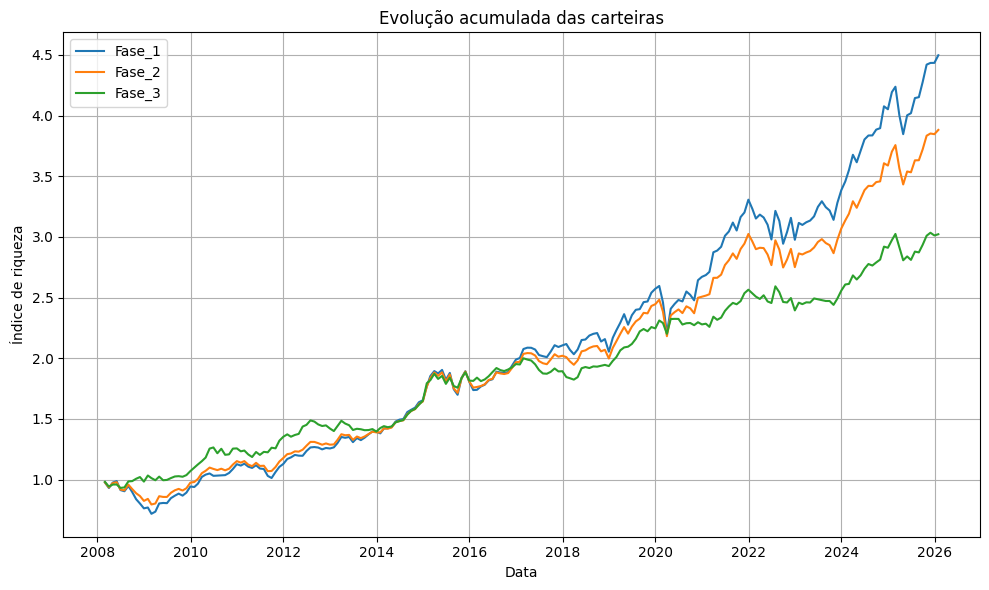

In [14]:
plt.figure(figsize=(10, 6))
for col in portfolio_wealth.columns:
    plt.plot(portfolio_wealth.index, portfolio_wealth[col], label=col)
plt.title("Evolução acumulada das carteiras")
plt.xlabel("Data")
plt.ylabel("Índice de riqueza")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 15. Gráfico — Drawdowns das Carteiras

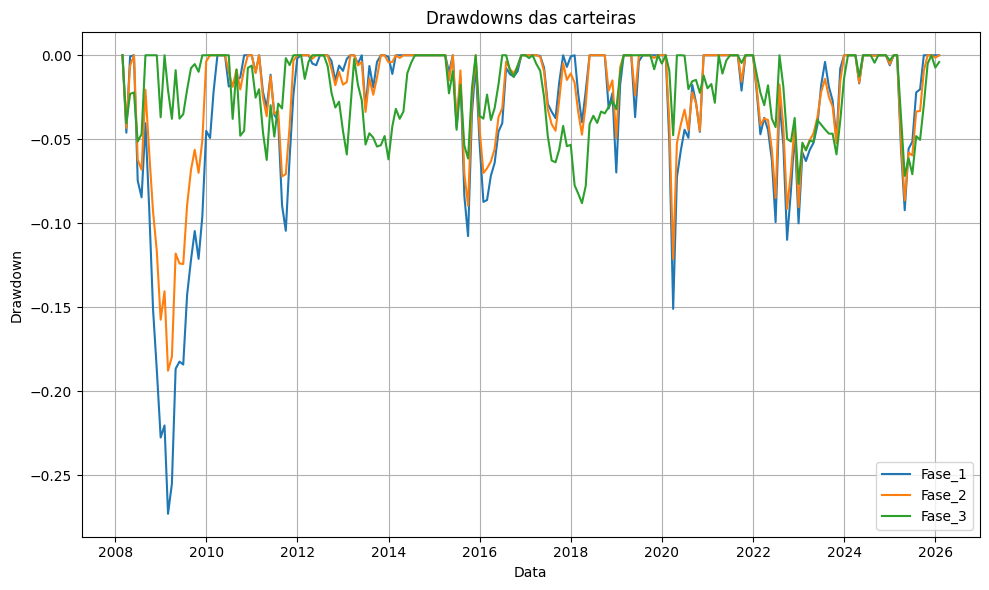

In [15]:
plt.figure(figsize=(10, 6))
for col in portfolio_drawdowns.columns:
    plt.plot(portfolio_drawdowns.index, portfolio_drawdowns[col], label=col)
plt.title("Drawdowns das carteiras")
plt.xlabel("Data")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 16. Otimização com Restrições por Fase (Backtest)

Fronteira eficiente, carteira atual e carteira otimizada com base em dados históricos.

In [16]:
from scipy.optimize import minimize

RISK_FREE_RATE = asset_returns["Liquidez"].mean() * 12
N_POINTS_FRONTIER = 60

constraints_by_phase = {
    "Fase_1": {
        "Acoes_EUA": (0.35, 0.45),
        "Acoes_Europa": (0.20, 0.30),
        "Emergentes": (0.08, 0.12),
        "Obrigacoes": (0.15, 0.25),
        "Ouro": (0.03, 0.07),
        "Liquidez": (0.00, 0.00)
    },
    "Fase_2": {
        "Acoes_EUA": (0.25, 0.35),
        "Acoes_Europa": (0.20, 0.30),
        "Emergentes": (0.03, 0.07),
        "Obrigacoes": (0.30, 0.40),
        "Ouro": (0.03, 0.07),
        "Liquidez": (0.00, 0.00)
    },
    "Fase_3": {
        "Acoes_EUA": (0.10, 0.20),
        "Acoes_Europa": (0.05, 0.15),
        "Emergentes": (0.00, 0.00),
        "Obrigacoes": (0.55, 0.65),
        "Ouro": (0.08, 0.12),
        "Liquidez": (0.03, 0.07)
    }
}

def portfolio_return(w, mean_returns):
    return np.dot(w, mean_returns)

def portfolio_volatility(w, cov_matrix):
    return np.sqrt(np.dot(w.T, np.dot(cov_matrix, w)))

def portfolio_sharpe(w, mean_returns, cov_matrix, risk_free_rate):
    ret = portfolio_return(w, mean_returns)
    vol = portfolio_volatility(w, cov_matrix)
    return np.nan if vol == 0 else (ret - risk_free_rate) / vol

def negative_sharpe(w, mean_returns, cov_matrix, risk_free_rate):
    return -portfolio_sharpe(w, mean_returns, cov_matrix, risk_free_rate)

def weight_sum_constraint(w):
    return np.sum(w) - 1

def get_active_assets(portfolio_name):
    phase_constraints = constraints_by_phase[portfolio_name]
    return [asset for asset, bounds in phase_constraints.items() if bounds[1] > 0]

def get_phase_bounds(portfolio_name, active_assets):
    phase_constraints = constraints_by_phase[portfolio_name]
    return tuple(phase_constraints[asset] for asset in active_assets)

def optimize_max_sharpe_constrained(mean_returns, cov_matrix, bounds, risk_free_rate):
    x0 = np.array([(low + high) / 2 for low, high in bounds], dtype=float)
    x0 = x0 / x0.sum()

    return minimize(
        negative_sharpe,
        x0=x0,
        args=(mean_returns, cov_matrix, risk_free_rate),
        method="SLSQP",
        bounds=bounds,
        constraints=({"type": "eq", "fun": weight_sum_constraint},)
    )

def minimize_volatility_for_target_return_constrained(target_return, mean_returns, cov_matrix, bounds):
    x0 = np.array([(low + high) / 2 for low, high in bounds], dtype=float)
    x0 = x0 / x0.sum()

    return minimize(
        portfolio_volatility,
        x0=x0,
        args=(cov_matrix,),
        method="SLSQP",
        bounds=bounds,
        constraints=(
            {"type": "eq", "fun": weight_sum_constraint},
            {"type": "eq", "fun": lambda w: portfolio_return(w, mean_returns) - target_return}
        )
    )

def build_constrained_frontier(mean_returns, cov_matrix, bounds, n_points=60, risk_free_rate=0.0):
    min_ret = sum(low * r for (low, high), r in zip(bounds, mean_returns))
    max_ret = sum(high * r for (low, high), r in zip(bounds, mean_returns))
    frontier = []

    for target in np.linspace(min_ret, max_ret, n_points):
        result = minimize_volatility_for_target_return_constrained(
            target, mean_returns, cov_matrix, bounds
        )

        if result.success:
            w = result.x
            frontier.append({
                "Retorno": portfolio_return(w, mean_returns),
                "Volatilidade": portfolio_volatility(w, cov_matrix),
                "Sharpe": portfolio_sharpe(w, mean_returns, cov_matrix, risk_free_rate),
                "Pesos": w
            })

    return pd.DataFrame(frontier)

def _slice_returns_and_cov(expected_returns, covariance_matrix, active_assets):
    """Aceita Series/DataFrame e devolve arrays alinhados com active_assets."""
    if isinstance(expected_returns, pd.Series):
        mean_returns = expected_returns.reindex(active_assets).astype(float).values
    else:
        mean_returns = pd.Series(expected_returns, index=active_assets).astype(float).values

    if isinstance(covariance_matrix, pd.DataFrame):
        cov_matrix = covariance_matrix.loc[active_assets, active_assets].astype(float).values
    else:
        cov_matrix = np.asarray(covariance_matrix, dtype=float)

    return mean_returns, cov_matrix

def analyze_frontier_for_phase(
    portfolio_name,
    expected_returns,
    covariance_matrix,
    risk_free_rate,
    scenario_label,
    frontier_label="Fronteira Eficiente",
    current_label="Carteira IPS",
    optimized_label="Carteira Otimizada",
    title_prefix="Relação Risco-Retorno",
    show_plot=True,
    show_output=True
):
    """Calcula fronteira, carteira IPS e carteira otimizada para qualquer cenário."""
    active_assets = get_active_assets(portfolio_name)
    mean_returns, cov_matrix = _slice_returns_and_cov(expected_returns, covariance_matrix, active_assets)
    bounds = get_phase_bounds(portfolio_name, active_assets)

    frontier_df = build_constrained_frontier(
        mean_returns,
        cov_matrix,
        bounds,
        n_points=N_POINTS_FRONTIER,
        risk_free_rate=risk_free_rate
    )

    # Filtrar apenas a parte eficiente da fronteira.
    if not frontier_df.empty:
        frontier_df = frontier_df.sort_values("Volatilidade").copy()
        frontier_df["Retorno_Max_Ate_Aqui"] = frontier_df["Retorno"].cummax()
        frontier_df = frontier_df[
            frontier_df["Retorno"] >= frontier_df["Retorno_Max_Ate_Aqui"] - 1e-8
        ].copy()
        frontier_df = frontier_df.drop(columns=["Retorno_Max_Ate_Aqui"])

    current_weights = weights[portfolio_name].reindex(active_assets).fillna(0).astype(float)
    current_weights = current_weights / current_weights.sum()
    current_return = portfolio_return(current_weights.values, mean_returns)
    current_vol = portfolio_volatility(current_weights.values, cov_matrix)
    current_sharpe = portfolio_sharpe(current_weights.values, mean_returns, cov_matrix, risk_free_rate)

    opt_result = optimize_max_sharpe_constrained(mean_returns, cov_matrix, bounds, risk_free_rate)

    if not opt_result.success:
        print(f"Falha na otimização da {portfolio_name} ({scenario_label}): {opt_result.message}")
        return None

    opt_weights = pd.Series(opt_result.x, index=active_assets)
    opt_return = portfolio_return(opt_weights.values, mean_returns)
    opt_vol = portfolio_volatility(opt_weights.values, cov_matrix)
    opt_sharpe = portfolio_sharpe(opt_weights.values, mean_returns, cov_matrix, risk_free_rate)

    if show_plot:
        fig, ax = plt.subplots(figsize=(10, 7), facecolor="white")
        ax.set_facecolor("white")

        scatter = ax.scatter(
            frontier_df["Volatilidade"] * 100,
            frontier_df["Retorno"] * 100,
            c=frontier_df["Sharpe"],
            cmap="Blues",
            s=60,
            alpha=0.90,
            edgecolors="black",
            linewidths=0.3,
            label=frontier_label
        )

        ax.plot(
            frontier_df["Volatilidade"] * 100,
            frontier_df["Retorno"] * 100,
            color="gray",
            alpha=0.45,
            linewidth=1
        )

        ax.scatter(
            current_vol * 100,
            current_return * 100,
            marker="D",
            s=130,
            color="#F4A261",
            edgecolors="black",
            linewidths=0.8,
            label=current_label,
            zorder=5
        )

        ax.scatter(
            opt_vol * 100,
            opt_return * 100,
            marker="*",
            s=280,
            color="#2A9D8F",
            edgecolors="black",
            linewidths=0.8,
            label=optimized_label,
            zorder=6
        )

        ax.annotate(
            current_label,
            (current_vol * 100, current_return * 100),
            xytext=(8, 8),
            textcoords="offset points",
            fontsize=10
        )

        ax.annotate(
            optimized_label,
            (opt_vol * 100, opt_return * 100),
            xytext=(8, -14),
            textcoords="offset points",
            fontsize=10
        )

        ax.set_title(f"{title_prefix} — {portfolio_name} ({scenario_label})", fontsize=16, pad=14)
        ax.set_xlabel("Volatilidade anualizada %", fontsize=13)
        ax.set_ylabel("Retorno esperado anualizado %", fontsize=13)
        # Escala dinâmica com margem controlada
        x_values = np.concatenate([
            frontier_df["Volatilidade"].values * 100,
            [current_vol * 100, opt_vol * 100]
        ])

        y_values = np.concatenate([
            frontier_df["Retorno"].values * 100,
            [current_return * 100, opt_return * 100]
        ])

        x_min, x_max = x_values.min(), x_values.max()
        y_min, y_max = y_values.min(), y_values.max()

        x_margin = max((x_max - x_min) * 0.20, 0.30)
        y_margin = max((y_max - y_min) * 0.25, 0.30)

        ax.set_xlim(x_min - x_margin, x_max + x_margin)
        ax.set_ylim(y_min - y_margin, y_max + y_margin)
        ax.grid(True, alpha=0.25)
        ax.legend(facecolor="white", edgecolor="black", framealpha=1, fontsize=10, loc="upper left")
        plt.colorbar(scatter, ax=ax, shrink=0.82).set_label("Sharpe Ratio", fontsize=12)
        plt.tight_layout()
        plt.show()

    if show_output:
        print("=" * 75)
        print(f"{portfolio_name} — {scenario_label}")
        print("Pesos IPS:")
        print(current_weights.apply(lambda x: f"{x:.2%}"))
        print("\nPesos otimizados:")
        print(opt_weights.apply(lambda x: f"{x:.2%}"))

        resumo = pd.DataFrame({
            "Métrica": ["Retorno anualizado", "Volatilidade anualizada", "Sharpe"],
            "Carteira IPS": [current_return, current_vol, current_sharpe],
            "Carteira Otimizada": [opt_return, opt_vol, opt_sharpe],
        })

        print("\nResumo comparativo:")
        print(resumo.to_string(index=False, formatters={
            "Carteira IPS": lambda x: f"{x:.2%}" if abs(x) < 1 else f"{x:.2f}",
            "Carteira Otimizada": lambda x: f"{x:.2%}" if abs(x) < 1 else f"{x:.2f}",
        }))

    return {
        "phase": portfolio_name,
        "scenario": scenario_label,
        "active_assets": active_assets,
        "frontier": frontier_df,
        "ips_weights": current_weights,
        "opt_weights": opt_weights,
        "opt_weights_cme": opt_weights,
        "ips_ret": current_return,
        "ips_vol": current_vol,
        "ips_sharpe": current_sharpe,
        "opt_ret": opt_return,
        "opt_vol": opt_vol,
        "opt_sharpe": opt_sharpe,
        "opt_ret_cme": opt_return,
        "opt_vol_cme": opt_vol,
        "opt_sharpe_cme": opt_sharpe,
    }

print("Funções de otimização carregadas e consolidadas.")

Funções de otimização carregadas e consolidadas.


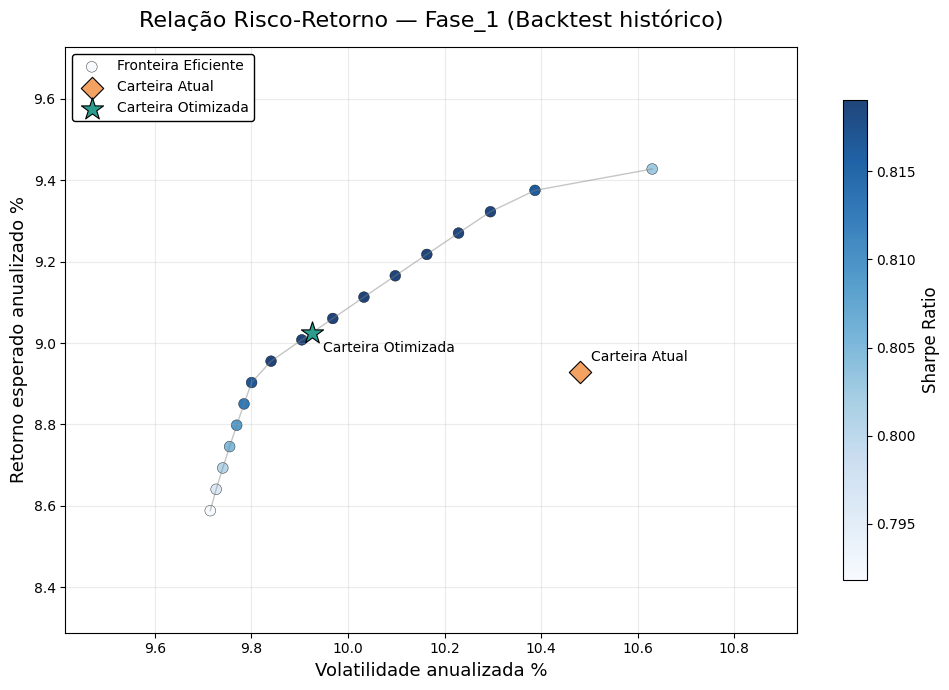

Fase_1 — Backtest histórico
Pesos IPS:
Acoes_EUA       40.00%
Acoes_Europa    25.00%
Emergentes      10.00%
Obrigacoes      20.00%
Ouro             5.00%
Name: Fase_1, dtype: object

Pesos otimizados:
Acoes_EUA       41.11%
Acoes_Europa    20.00%
Emergentes       8.00%
Obrigacoes      23.89%
Ouro             7.00%
dtype: object

Resumo comparativo:
                Métrica Carteira IPS Carteira Otimizada
     Retorno anualizado        8.93%              9.03%
Volatilidade anualizada       10.48%              9.93%
                 Sharpe       76.66%             81.91%


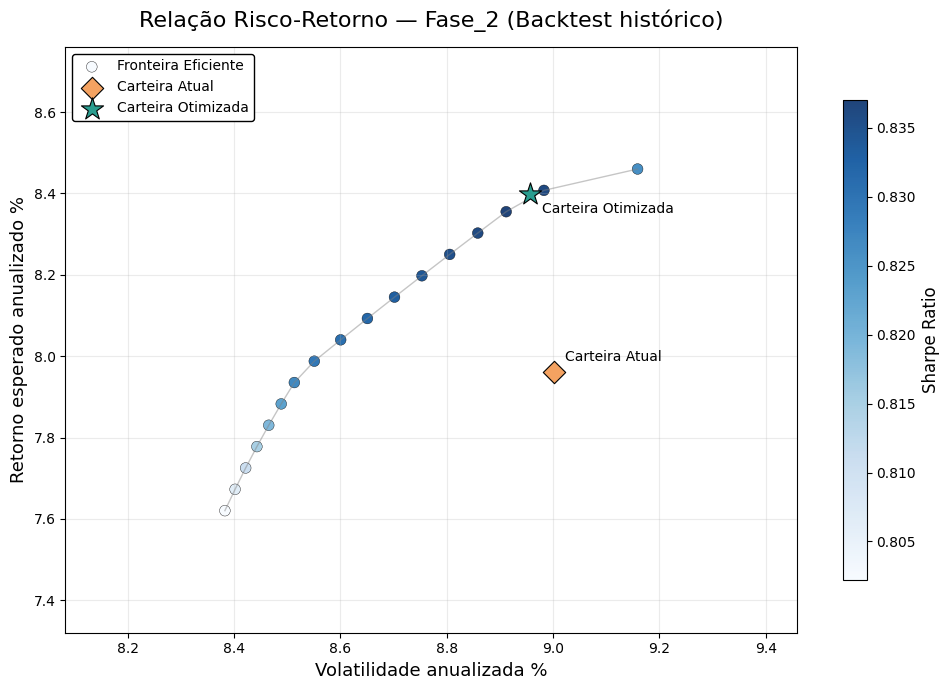

Fase_2 — Backtest histórico
Pesos IPS:
Acoes_EUA       30.00%
Acoes_Europa    25.00%
Emergentes       5.00%
Obrigacoes      35.00%
Ouro             5.00%
Name: Fase_2, dtype: object

Pesos otimizados:
Acoes_EUA       35.00%
Acoes_Europa    20.00%
Emergentes       3.00%
Obrigacoes      35.00%
Ouro             7.00%
dtype: object

Resumo comparativo:
                Métrica Carteira IPS Carteira Otimizada
     Retorno anualizado        7.96%              8.40%
Volatilidade anualizada        9.00%              8.96%
                 Sharpe       78.49%             83.77%


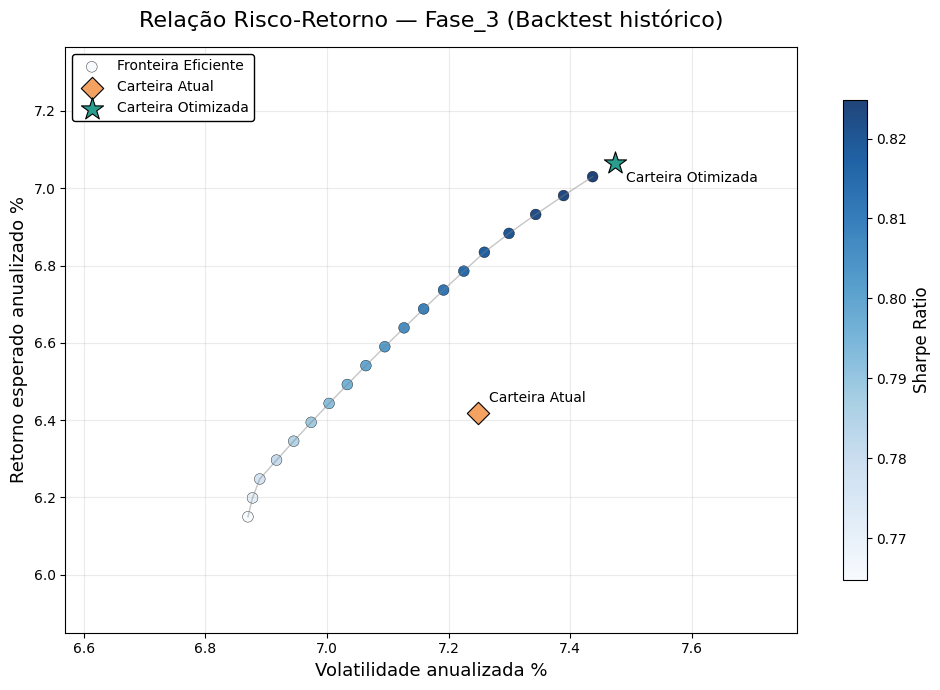

Fase_3 — Backtest histórico
Pesos IPS:
Acoes_EUA       15.00%
Acoes_Europa    10.00%
Obrigacoes      60.00%
Ouro            10.00%
Liquidez         5.00%
Name: Fase_3, dtype: object

Pesos otimizados:
Acoes_EUA       20.00%
Acoes_Europa    10.00%
Obrigacoes      55.00%
Ouro            12.00%
Liquidez         3.00%
dtype: object

Resumo comparativo:
                Métrica Carteira IPS Carteira Otimizada
     Retorno anualizado        6.42%              7.07%
Volatilidade anualizada        7.25%              7.47%
                 Sharpe       76.20%             82.57%


In [17]:
historical_optimization_results = {}

for phase in ["Fase_1", "Fase_2", "Fase_3"]:
    active_assets = get_active_assets(phase)
    mean_hist = asset_returns[active_assets].mean() * 12
    cov_hist  = asset_returns[active_assets].cov() * 12

    historical_optimization_results[phase] = analyze_frontier_for_phase(
        portfolio_name=phase,
        expected_returns=mean_hist,
        covariance_matrix=cov_hist,
        risk_free_rate=RISK_FREE_RATE,
        scenario_label="Backtest histórico",
        frontier_label="Fronteira Eficiente",
        current_label="Carteira Atual",
        optimized_label="Carteira Otimizada",
        title_prefix="Relação Risco-Retorno"
    )

---
# Capital Market Expectations

Este módulo substitui as médias históricas como inputs da otimização, incorporando o contexto macroeconómico atual.

**Modelos utilizados:**
- **Ações EUA / Europa** → Grinold-Kroner completo (dividendo + buyback + crescimento EPS + rerating P/E)
- **Emergentes** → Singer-Terhaar (ICAPM) + Grinold-Kroner (triangulação)
- **Obrigações** → Building Blocks (YTM + ganho capital + ajuste crédito)
- **Ouro** → Erb-Harvey Real Yield Model

## CME 1. Pressupostos Macroeconómicos

In [18]:
import matplotlib.ticker as mticker

macro = {

    # Taxa livre de risco estrutural para CME de longo prazo
    # Justificação: horizonte de 35 anos; evita extrapolar a taxa monetária corrente.
    # Construção: taxa nominal de longo prazo ≈ inflação esperada BCE (2.0%) + r* real neutra (0.5%).
    # A r* não é observável diretamente; é uma estimativa/pressuposto prudente suportado pela literatura
    # de bancos centrais sobre a taxa natural de juro.
    "taxa_real_neutra":              0.005,
    "taxa_livre_risco_longo_prazo":  0.025,

    # Inflação
    "inflacao": 0.02,   # inflação esperada nominal de longo prazo; objetivo BCE/Fed

    # Crescimento real PIB — FMI WEO abr 2026
    "pib_real_EUR": 0.013,   # ECB SPF Q2 2026
    "pib_real_USD": 0.02,   # FOMC SEP de junho de 2026
    "pib_real_EM":  0.039,   # FMI WEO abr 2026: 3.9%

    "yield_ust_10y":  0.0450,  # UST 10Y, junho 2026

    # S&P 500
    "div_yield_SP500":            0.0105,  # S&P 500 dividend yield, junho 2026 (GuruFocus/MacroMicro)
    "buyback_yield_SP500":        0.0130,  # recompras líquidas ~1.3%; buybacks $1T+ / mkt cap ~$50T
    "crescimento_eps_eua_nominal": 0.04,   # PIB real 2.0% + inflação USD 2.0%
    "pe_atual_SP500":             22.0,    # forward PE (MacroMicro); trailing PE mais elevado
    "pe_alvo_SP500":              19.0,    # revisto em baixa face a taxas mais altas e inflação persistente
    "horizonte_rerating_anos":    10,

    # MSCI Europe (fonte: iShares IMEU, junho 2026)
    "div_yield_Europa":             0.0255,  # IMEU trailing dividend yield, jun 2026
    "buyback_yield_Europa":         0.005,   # recompras europeias estruturalmente baixas
    "crescimento_eps_europa_nominal": 0.033,  # PIB real ZE 1.3% + inflação EUR 2.0%
    "pe_atual_Europa":              18.5,    # P/E IMEU, junho 2026 (~18.3–18.7)
    "pe_alvo_Europa":               16.0,    # revisto em baixa; BCE em ciclo de subida, valuation subiu

    # MSCI Emerging Markets (fonte: EEM, junho 2026)
    "div_yield_EM":            0.020,    # EEM dividend yield, junho 2026
    "buyback_yield_EM":        0.005,
    "crescimento_eps_em_nominal": 0.059, # PIB real EM 3.9% + inflação implícita 2.0%
    "pe_atual_EM":             13.0,     # EEM P/E trailing ~12.9; arredondado
    "pe_alvo_EM":              13.0,     # neutro; EM valuation razoável vs. histórico
    "grau_integracao_EM":      0.65,     # CFA: ~0.65 para EM
    "sharpe_GIM":              0.35,     # Sharpe do Global Investable Market
    "vol_GIM":                 0.09,

    # Bloomberg US Aggregate Bond
    "ytm_agg_usd":       0.0450,  # YTM ~4.5%, consistente com UST 10Y, junho 2026
    "duration_agg":      5.8,     # duration modificada, março 2026 (Hartford Funds)
    "delta_yield_agg":   0.000,   # variação esperada de yield — neutro no cenário central
    "perda_credito_agg": 0.001,

    # Ouro — Erb-Harvey
    "yield_real_usd_10y":     0.023,  # UST 10Y 4.50% − breakeven TIPS ~2.2%, junho 2026
    "premio_refugio_ouro":    0.005,
    "beta_ouro_yield_real":   1.0,
}

print("Pressupostos macroeconómicos carregados.")
for k, v in macro.items():
    if isinstance(v, float) and abs(v) < 10:
        print(f"  {k:<42} {v:.2%}" if abs(v) < 1 else f"  {k:<42} {v:.2f}")

Pressupostos macroeconómicos carregados.
  taxa_real_neutra                           0.50%
  taxa_livre_risco_longo_prazo               2.50%
  inflacao                                   2.00%
  pib_real_EUR                               1.30%
  pib_real_USD                               2.00%
  pib_real_EM                                3.90%
  yield_ust_10y                              4.50%
  div_yield_SP500                            1.05%
  buyback_yield_SP500                        1.30%
  crescimento_eps_eua_nominal                4.00%
  div_yield_Europa                           2.55%
  buyback_yield_Europa                       0.50%
  crescimento_eps_europa_nominal             3.30%
  div_yield_EM                               2.00%
  buyback_yield_EM                           0.50%
  crescimento_eps_em_nominal                 5.90%
  grau_integracao_EM                         65.00%
  sharpe_GIM                                 35.00%
  vol_GIM                              

## CME 2. Grinold-Kroner — Ações EUA e Europa

**E[R] = DY − ΔS + ΔEarnings + ΔP/E**

| Componente | Descrição |
|---|---|
| DY | Dividend yield atual |
| −ΔS | Buyback yield (recompras líquidas) |
| ΔEarnings | Crescimento nominal esperado de EPS |
| ΔP/E | Rerating do múltiplo de avaliação |

*Fonte: Grinold & Kroner (2002); CFA Curriculum Level 3, Vol.1, Cap.2*

In [19]:
def grinold_kroner(div_yield, buyback_yield, earnings_growth,
                   pe_atual, pe_alvo, horizonte_anos,
                   aplicar_rerating=True):
    """
    Modelo Grinold-Kroner.
    Se aplicar_rerating=False, assume ΔP/E = 0,
    adequado para fases posteriores ao horizonte de convergência.
    """
    if aplicar_rerating:
        delta_pe = (pe_alvo / pe_atual) ** (1 / horizonte_anos) - 1
    else:
        delta_pe = 0.0

    retorno = div_yield + buyback_yield + earnings_growth + delta_pe

    componentes = {
        "Dividend Yield": div_yield,
        "Buyback Yield": buyback_yield,
        "Crescimento Earnings": earnings_growth,
        "Rerating P/E (anual)": delta_pe,
        "Retorno Total": retorno,
    }

    return retorno, componentes

# Ações EUA — Fase 1, com rerating
cme_acoes_eua_f1, comp_eua_f1 = grinold_kroner(
    div_yield=macro["div_yield_SP500"],
    buyback_yield=macro["buyback_yield_SP500"],
    earnings_growth=macro["crescimento_eps_eua_nominal"],
    pe_atual=macro["pe_atual_SP500"],
    pe_alvo=macro["pe_alvo_SP500"],
    horizonte_anos=macro["horizonte_rerating_anos"],
    aplicar_rerating=True
)

# Ações EUA — Fases 2 e 3, sem rerating
cme_acoes_eua_f2f3, comp_eua_f2f3 = grinold_kroner(
    div_yield=macro["div_yield_SP500"],
    buyback_yield=macro["buyback_yield_SP500"],
    earnings_growth=macro["crescimento_eps_eua_nominal"],
    pe_atual=macro["pe_atual_SP500"],
    pe_alvo=macro["pe_alvo_SP500"],
    horizonte_anos=macro["horizonte_rerating_anos"],
    aplicar_rerating=False
)

# Variáveis de compatibilidade para o resto do notebook
# Mantêm o valor da Fase 1 no vetor CME central.
cme_acoes_eua = cme_acoes_eua_f1
comp_eua = comp_eua_f1

print("=" * 70)
print("GRINOLD-KRONER — AÇÕES EUA (S&P 500)")
print("=" * 70)
print("Fase 1 — com rerating P/E")
for k, v in comp_eua_f1.items():
    print(f"  {k:<32} {v:>8.2%}")

print("\nFases 2 e 3 — sem rerating P/E")
for k, v in comp_eua_f2f3.items():
    print(f"  {k:<32} {v:>8.2%}")

print(f"\n  {'CME Fase 1:':<32} {cme_acoes_eua_f1:>8.2%}")
print(f"  {'CME Fases 2 e 3:':<32} {cme_acoes_eua_f2f3:>8.2%}")


# Ações Europa — Fase 1, com rerating
cme_acoes_europa_f1, comp_europa_f1 = grinold_kroner(
    div_yield=macro["div_yield_Europa"],
    buyback_yield=macro["buyback_yield_Europa"],
    earnings_growth=macro["crescimento_eps_europa_nominal"],
    pe_atual=macro["pe_atual_Europa"],
    pe_alvo=macro["pe_alvo_Europa"],
    horizonte_anos=macro["horizonte_rerating_anos"],
    aplicar_rerating=True
)

# Ações Europa — Fases 2 e 3, sem rerating
cme_acoes_europa_f2f3, comp_europa_f2f3 = grinold_kroner(
    div_yield=macro["div_yield_Europa"],
    buyback_yield=macro["buyback_yield_Europa"],
    earnings_growth=macro["crescimento_eps_europa_nominal"],
    pe_atual=macro["pe_atual_Europa"],
    pe_alvo=macro["pe_alvo_Europa"],
    horizonte_anos=macro["horizonte_rerating_anos"],
    aplicar_rerating=False
)

# Variáveis de compatibilidade para o resto do notebook
# Mantêm o valor da Fase 1 no vetor CME central.
cme_acoes_europa = cme_acoes_europa_f1
comp_europa = comp_europa_f1

print()
print("=" * 70)
print("GRINOLD-KRONER — AÇÕES EUROPA (MSCI EUROPE)")
print("=" * 70)
print("Fase 1 — com rerating P/E")
for k, v in comp_europa_f1.items():
    print(f"  {k:<32} {v:>8.2%}")

print("\nFases 2 e 3 — sem rerating P/E")
for k, v in comp_europa_f2f3.items():
    print(f"  {k:<32} {v:>8.2%}")

print(f"\n  {'CME Fase 1:':<32} {cme_acoes_europa_f1:>8.2%}")
print(f"  {'CME Fases 2 e 3:':<32} {cme_acoes_europa_f2f3:>8.2%}")

GRINOLD-KRONER — AÇÕES EUA (S&P 500)
Fase 1 — com rerating P/E
  Dividend Yield                      1.05%
  Buyback Yield                       1.30%
  Crescimento Earnings                4.00%
  Rerating P/E (anual)               -1.46%
  Retorno Total                       4.89%

Fases 2 e 3 — sem rerating P/E
  Dividend Yield                      1.05%
  Buyback Yield                       1.30%
  Crescimento Earnings                4.00%
  Rerating P/E (anual)                0.00%
  Retorno Total                       6.35%

  CME Fase 1:                         4.89%
  CME Fases 2 e 3:                    6.35%

GRINOLD-KRONER — AÇÕES EUROPA (MSCI EUROPE)
Fase 1 — com rerating P/E
  Dividend Yield                      2.55%
  Buyback Yield                       0.50%
  Crescimento Earnings                3.30%
  Rerating P/E (anual)               -1.44%
  Retorno Total                       4.91%

Fases 2 e 3 — sem rerating P/E
  Dividend Yield                      2.55%
  Buyback

## CME 3. Singer-Terhaar — Mercados Emergentes

Para mercados parcialmente integrados, o CFA usa o modelo ICAPM de Singer-Terhaar:

**ERP_i = λ × ERP_integrado + (1−λ) × ERP_segmentado**

- **ERP integrado** = ρ(i, GIM) × σ_i × Sharpe_GIM
- **ERP segmentado** = σ_i × Sharpe_GIM
- **λ** = grau de integração (≈ 0.65 para Emergentes)

O resultado é triangulado com o Grinold-Kroner.

*Fonte: Singer & Terhaar (1997); CFA Curriculum Level 3, Vol.1, Cap.2*

In [20]:
def singer_terhaar(vol_ativo, corr_com_gim, sharpe_gim,
                   grau_integracao, risk_free_rate):
    """
    Singer-Terhaar (ICAPM) para mercados parcialmente integrados.
    CFA Level 3, Volume 1, Capítulo 2.
    """
    erp_integrado  = corr_com_gim * vol_ativo * sharpe_gim
    erp_segmentado = vol_ativo * sharpe_gim
    erp_total = (grau_integracao * erp_integrado +
                 (1 - grau_integracao) * erp_segmentado)
    retorno_esperado = risk_free_rate + erp_total
    detalhes = {
        "ERP integrado":      erp_integrado,
        "ERP segmentado":     erp_segmentado,
        "Grau de integração": grau_integracao,
        "ERP ajustado":       erp_total,
        "Retorno esperado":   retorno_esperado,
    }
    return retorno_esperado, erp_total, detalhes

VOL_EM_ESTIMADA = 0.20   # volatilidade histórica EM ~20% anualizada
CORR_EM_GIM     = 0.80   # correlação histórica EM com GIM

cme_em_st_usd, erp_em, detalhes_st = singer_terhaar(
    vol_ativo       = VOL_EM_ESTIMADA,
    corr_com_gim    = CORR_EM_GIM,
    sharpe_gim      = macro["sharpe_GIM"],
    grau_integracao = macro["grau_integracao_EM"],
    risk_free_rate  = macro["yield_ust_10y"]
)

cme_em_gk_usd, comp_em = grinold_kroner(
    div_yield       = macro["div_yield_EM"],
    buyback_yield   = macro["buyback_yield_EM"],
    earnings_growth = macro["crescimento_eps_em_nominal"],
    pe_atual        = macro["pe_atual_EM"],
    pe_alvo         = macro["pe_alvo_EM"],
    horizonte_anos  = macro["horizonte_rerating_anos"],
)

# Triangulação: média Singer-Terhaar e Grinold-Kroner
cme_emergentes_usd = (cme_em_st_usd + cme_em_gk_usd) / 2
cme_emergentes     = cme_emergentes_usd

print("=" * 55)
print("SINGER-TERHAAR — EMERGENTES (MSCI EM)")
print("=" * 55)
for k, v in detalhes_st.items():
    print(f"  {k:<30} {v:>8.2%}" if isinstance(v, float) else f"  {k:<30} {v:>8.2f}")
print()
print("GRINOLD-KRONER (confirmação):")
for k, v in comp_em.items():
    print(f"  {k:<30} {v:>8.2%}")
print()
print(f"  Singer-Terhaar USD:           {cme_em_st_usd:>8.2%}")
print(f"  Grinold-Kroner USD:           {cme_em_gk_usd:>8.2%}")
print(f"  CME EM USD (triangulação):    {cme_emergentes_usd:>8.2%}")
print(f"  CME EM EUR:                   {cme_emergentes:>8.2%}")

SINGER-TERHAAR — EMERGENTES (MSCI EM)
  ERP integrado                     5.60%
  ERP segmentado                    7.00%
  Grau de integração               65.00%
  ERP ajustado                      6.09%
  Retorno esperado                 10.59%

GRINOLD-KRONER (confirmação):
  Dividend Yield                    2.00%
  Buyback Yield                     0.50%
  Crescimento Earnings              5.90%
  Rerating P/E (anual)              0.00%
  Retorno Total                     8.40%

  Singer-Terhaar USD:             10.59%
  Grinold-Kroner USD:              8.40%
  CME EM USD (triangulação):       9.50%
  CME EM EUR:                      9.50%


## CME 4. Building Blocks — Obrigações

**E[R] = YTM − Duration × Δyield − Perda_Crédito**

| Componente | Descrição |
|---|---|
| YTM | Yield accrual — melhor estimador não enviesado do retorno |
| −Duration × Δyield | Ganho/perda de capital por variação de yields |
| −Perda Crédito | Perdas esperadas por incumprimento e downgrade |

*Fonte: CFA Curriculum Level 3, Vol.1, Cap.2*

In [21]:
def building_blocks_bonds(ytm, duration, delta_yield, perda_credito):
    """
    Building Blocks para obrigações — CFA Level 3.
    """
    yield_accrual  = ytm
    ganho_capital  = -duration * delta_yield
    ajuste_credito = -perda_credito
    retorno = yield_accrual + ganho_capital + ajuste_credito
    componentes = {
        "YTM (yield accrual)":    yield_accrual,
        "Ganho/perda capital":    ganho_capital,
        "Ajuste crédito":         ajuste_credito,
        "Retorno Total":          retorno,
    }
    return retorno, componentes

cme_obrigacoes_usd, comp_bonds = building_blocks_bonds(
    ytm           = macro["ytm_agg_usd"],
    duration      = macro["duration_agg"],
    delta_yield   = macro["delta_yield_agg"],
    perda_credito = macro["perda_credito_agg"],
)
cme_obrigacoes = cme_obrigacoes_usd

print("=" * 55)
print("BUILDING BLOCKS — OBRIGAÇÕES (Bloomberg US AGG)")
print("=" * 55)
for k, v in comp_bonds.items():
    print(f"  {k:<30} {v:>8.2%}")
print(f"  {'Retorno em USD:':<30} {cme_obrigacoes_usd:>8.2%}")
print(f"  {'CME em EUR:':<30} {cme_obrigacoes:>8.2%}")

BUILDING BLOCKS — OBRIGAÇÕES (Bloomberg US AGG)
  YTM (yield accrual)               4.50%
  Ganho/perda capital              -0.00%
  Ajuste crédito                   -0.10%
  Retorno Total                     4.40%
  Retorno em USD:                   4.40%
  CME em EUR:                       4.40%


## CME 5. Erb-Harvey — Ouro com mean reversion da yield real por fase

O ouro não paga dividendos. O seu retorno real é negativamente correlacionado com a yield real de longo prazo (custo de oportunidade):

**Retorno real = −β × yield_real + prémio_refúgio**

**Retorno nominal = (1 + retorno real) × (1 + inflação) − 1**

Yield real positiva é um headwind para o ouro; negativa é um tailwind.

O modelo Erb-Harvey assume yield real constante, o que é irrealista num horizonte de 35 anos. Yields reais tendem a reverter para a média histórica de longo prazo (~0.5%–1.5%), consistente com os mercados de TIPS para prazos muito longos (Federal Reserve, 2026).

*Fonte: Erb & Harvey (2013), The Golden Dilemma, FAJ 69(4)*

In [22]:
def erb_harvey_gold(yield_real, beta_yield_real, premio_refugio, inflacao_esperada):
    """
    Erb-Harvey Real Yield Model para ouro.
    Erb, C. & Harvey, C. (2013). The Golden Dilemma. FAJ 69(4).
    """
    retorno_real    = -beta_yield_real * yield_real + premio_refugio
    retorno_nominal = (1 + retorno_real) * (1 + inflacao_esperada) - 1
    componentes = {
        "Custo oportunidade (−β×yield_real)": -beta_yield_real * yield_real,
        "Prémio de refúgio"                 : premio_refugio,
        "Retorno real esperado"             : retorno_real,
        "Inflação esperada (USD)"           : inflacao_esperada,
        "Retorno nominal (USD)"             : retorno_nominal,
    }
    return retorno_nominal, componentes

# ── Yield real por fase (mean reversion gradual) ──────────────────────────────
yield_real_por_fase = {
    "Fase_1": macro["yield_real_usd_10y"],  # 2.30% — contexto actual (2026)
    "Fase_2": 0.0150,                        # convergência gradual (10–25 anos)
    "Fase_3": 0.0100,                        # mean reversion longo prazo (25–35 anos)
}

# ── Cálculo por fase ──────────────────────────────────────────────────────────
cme_ouro_por_fase = {}

print("=" * 60)
print("ERB-HARVEY — OURO COM MEAN REVERSION DA YIELD REAL POR FASE")
print("=" * 60)
print(f"  {'Fase':<10} {'Yield real':>12} {'Ret. real':>12} {'Ret. nominal':>14}")
print(f"  {'-'*52}")

for fase, yr in yield_real_por_fase.items():
    ret_nominal, comp = erb_harvey_gold(
        yield_real        = yr,
        beta_yield_real   = macro["beta_ouro_yield_real"],
        premio_refugio    = macro["premio_refugio_ouro"],
        inflacao_esperada = macro["inflacao"],
    )
    cme_ouro_por_fase[fase] = ret_nominal
    ret_real = comp["Retorno real esperado"]
    print(f"  {fase:<10} {yr:>12.2%} {ret_real:>12.2%} {ret_nominal:>14.2%}")

print()
print("  Nota: Fase 1 usa a yield real actual de 2.30% (contexto 2026).")
print("  Fases 2 e 3 assumem convergência gradual para a média histórica")
print("  de longo prazo dos TIPS (Federal Reserve, 2026).")

# Detalhe da Fase 1 (para consistência com o Quadro 5 do relatório)
print()
print("=" * 55)
print("DETALHE — FASE 1 (yield real 2.30%, contexto actual)")
print("=" * 55)
_, comp_fase1 = erb_harvey_gold(
    yield_real        = yield_real_por_fase["Fase_1"],
    beta_yield_real   = macro["beta_ouro_yield_real"],
    premio_refugio    = macro["premio_refugio_ouro"],
    inflacao_esperada = macro["inflacao"],
)
for k, v in comp_fase1.items():
    print(f"  {k:<42} {v:>8.2%}")

# ── Variável de compatibilidade com CME 7 ─────────────────────────────────────
# cme_ouro e cme_ouro_usd continuam a usar o valor da Fase 1 (2.30%)
# para o Quadro 5 e para a otimização, que são análises de curto/médio prazo.
# O Monte Carlo usa cme_ouro_por_fase para incorporar a mean reversion.
cme_ouro     = cme_ouro_por_fase["Fase_1"]
cme_ouro_usd = cme_ouro_por_fase["Fase_1"]

print(f"\n  CME Ouro Quadro 5 / otimização (Fase 1): {cme_ouro:.2%}")
print(f"  CME Ouro Monte Carlo Fase 2             : {cme_ouro_por_fase['Fase_2']:.2%}")
print(f"  CME Ouro Monte Carlo Fase 3             : {cme_ouro_por_fase['Fase_3']:.2%}")

ERB-HARVEY — OURO COM MEAN REVERSION DA YIELD REAL POR FASE
  Fase         Yield real    Ret. real   Ret. nominal
  ----------------------------------------------------
  Fase_1            2.30%       -1.80%          0.16%
  Fase_2            1.50%       -1.00%          0.98%
  Fase_3            1.00%       -0.50%          1.49%

  Nota: Fase 1 usa a yield real actual de 2.30% (contexto 2026).
  Fases 2 e 3 assumem convergência gradual para a média histórica
  de longo prazo dos TIPS (Federal Reserve, 2026).

DETALHE — FASE 1 (yield real 2.30%, contexto actual)
  Custo oportunidade (−β×yield_real)           -2.30%
  Prémio de refúgio                             0.50%
  Retorno real esperado                        -1.80%
  Inflação esperada (USD)                       2.00%
  Retorno nominal (USD)                         0.16%

  CME Ouro Quadro 5 / otimização (Fase 1): 0.16%
  CME Ouro Monte Carlo Fase 2             : 0.98%
  CME Ouro Monte Carlo Fase 3             : 1.49%


## CME 6. Vetor Final de Retornos Esperados

In [23]:
cme_liquidez = macro["taxa_livre_risco_longo_prazo"]

cme_returns = pd.Series({
    "Acoes_EUA":    cme_acoes_eua,
    "Acoes_Europa": cme_acoes_europa,
    "Emergentes":   cme_emergentes,
    "Obrigacoes":   cme_obrigacoes,
    "Ouro":         cme_ouro,
    "Liquidez":     cme_liquidez,
})

modelos = {
    "Acoes_EUA":    "Grinold-Kroner; sem variação cambial esperada",
    "Acoes_Europa": "Grinold-Kroner",
    "Emergentes":   "Singer-Terhaar + GK; sem variação cambial esperada",
    "Obrigacoes":   "Building Blocks; sem variação cambial esperada",
    "Ouro":         "Erb-Harvey; sem variação cambial esperada",
    "Liquidez":     "Taxa livre de risco nominal de longo prazo: inflação esperada + taxa real neutra",
}

print("=" * 65)
print("CME — RETORNOS ESPERADOS ANUALIZADOS (EUR)")
print("=" * 65)
print(f"Taxa livre de risco CME de longo prazo: {macro['taxa_livre_risco_longo_prazo']:.2%} "
      f"= inflação esperada {macro['inflacao']:.2%} + r* real neutra {macro['taxa_real_neutra']:.2%}")
print()
print(f"  {'Ativo':<20} {'Retorno CME':>12}  Modelo")
print(f"  {'-'*60}")
for asset in cme_returns.index:
    print(f"  {asset:<20} {cme_returns[asset]:>12.2%}  {modelos[asset]}")

CME — RETORNOS ESPERADOS ANUALIZADOS (EUR)
Taxa livre de risco CME de longo prazo: 2.50% = inflação esperada 2.00% + r* real neutra 0.50%

  Ativo                 Retorno CME  Modelo
  ------------------------------------------------------------
  Acoes_EUA                   4.89%  Grinold-Kroner; sem variação cambial esperada
  Acoes_Europa                4.91%  Grinold-Kroner
  Emergentes                  9.50%  Singer-Terhaar + GK; sem variação cambial esperada
  Obrigacoes                  4.40%  Building Blocks; sem variação cambial esperada
  Ouro                        0.16%  Erb-Harvey; sem variação cambial esperada
  Liquidez                    2.50%  Taxa livre de risco nominal de longo prazo: inflação esperada + taxa real neutra


## CME 7. Volatilidade e Correlações Esperadas

In [24]:
hist_vol      = annualized_volatility(asset_returns)
hist_ret_geom = annualized_geometric_return(asset_returns)
hist_corr     = asset_returns.corr()

vol_adjustments = pd.Series({
    "Acoes_EUA":   -0.010,  # VIX normalizado; menor frequência de crises
    "Acoes_Europa": 0.000,  # geopolítica + crescimento fraco → estável
    "Emergentes":   0.010,  # risco cambial EM estruturalmente elevado
    "Obrigacoes":   0.015,  # regime pós-2022: taxas mais voláteis
    "Ouro":         0.000,  # procura bancos centrais compensa
    "Liquidez":     0.000,  # por definição ≈ 0
})

cme_vol  = (hist_vol + vol_adjustments).clip(lower=0.001)
cme_corr = hist_corr.copy()

# Ajuste 1: ações/obrigações → neutro (0.0)
# Regime pós-2022 rompeu correlação negativa histórica.
# Com inflação a ceder, expectativa de retorno a correlação neutra.
for acao in ["Acoes_EUA", "Acoes_Europa"]:
    cme_corr.loc[acao, "Obrigacoes"] = 0.00
    cme_corr.loc["Obrigacoes", acao] = 0.00

# Ajuste 2: EM/Europa → ligeiramente reduzida (divergência de ciclos)
em_europa = hist_corr.loc["Emergentes", "Acoes_Europa"]
cme_corr.loc["Emergentes", "Acoes_Europa"] = max(em_europa - 0.05, 0)
cme_corr.loc["Acoes_Europa", "Emergentes"] = cme_corr.loc["Emergentes", "Acoes_Europa"]

print("Volatilidade CME vs. histórica:")
print(f"  {'Ativo':<20} {'Vol Hist':>10} {'Ajuste':>10} {'Vol CME':>10}")
print(f"  {'-'*55}")
for asset in cme_vol.index:
    adj   = vol_adjustments[asset]
    sinal = "+" if adj >= 0 else ""
    print(f"  {asset:<20} {hist_vol[asset]:>10.2%} {sinal}{adj:>9.2%} {cme_vol[asset]:>10.2%}")

print()
print("CME — Correlações (com ajustes):")
print(cme_corr.round(3))

Volatilidade CME vs. histórica:
  Ativo                  Vol Hist     Ajuste    Vol CME
  -------------------------------------------------------
  Acoes_EUA                14.48%    -1.00%     13.48%
  Acoes_Europa             14.46% +    0.00%     14.46%
  Emergentes               16.72% +    1.00%     17.72%
  Obrigacoes                9.12% +    1.50%     10.62%
  Ouro                     16.11% +    0.00%     16.11%
  Liquidez                  0.45% +    0.00%      0.45%

CME — Correlações (com ajustes):
              Acoes_EUA  Acoes_Europa  Emergentes  Obrigacoes   Ouro  Liquidez
Acoes_EUA         1.000         0.778       0.629       0.000 -0.043    -0.108
Acoes_Europa      0.778         1.000       0.672       0.000 -0.112    -0.124
Emergentes        0.629         0.672       1.000      -0.119  0.068    -0.102
Obrigacoes        0.000         0.000      -0.119       1.000  0.289     0.043
Ouro             -0.043        -0.112       0.068       0.289  1.000     0.097
Liquidez   

In [25]:
# Matriz de covariância CME: Cov(i,j) = corr(i,j) × vol(i) × vol(j)
assets_all = cme_vol.index.tolist()
cme_cov = pd.DataFrame(index=assets_all, columns=assets_all, dtype=float)
for i in assets_all:
    for j in assets_all:
        cme_cov.loc[i, j] = cme_corr.loc[i, j] * cme_vol[i] * cme_vol[j]

print("CME — Matriz de Covariância:")
print(cme_cov.applymap(lambda x: f"{x:.5f}").to_string())

CME — Matriz de Covariância:
             Acoes_EUA Acoes_Europa Emergentes Obrigacoes      Ouro  Liquidez
Acoes_EUA      0.01817      0.01517    0.01502    0.00000  -0.00094  -0.00006
Acoes_Europa   0.01517      0.02092    0.01722    0.00000  -0.00261  -0.00008
Emergentes     0.01502      0.01722    0.03140   -0.00224   0.00193  -0.00008
Obrigacoes     0.00000      0.00000   -0.00224    0.01128   0.00495   0.00002
Ouro          -0.00094     -0.00261    0.00193    0.00495   0.02596   0.00007
Liquidez      -0.00006     -0.00008   -0.00008    0.00002   0.00007   0.00002


## CME 8. Comparação Histórico vs. CME

In [26]:
comparacao = pd.DataFrame({
    "Ret_Hist_Geom": hist_ret_geom,
    "Vol_Hist":      hist_vol,
    "Ret_CME":       cme_returns,
    "Vol_CME":       cme_vol,
}).dropna()

comparacao["Δ_Retorno"] = comparacao["Ret_CME"] - comparacao["Ret_Hist_Geom"]
comparacao["Δ_Vol"]     = comparacao["Vol_CME"]  - comparacao["Vol_Hist"]


print("Comparação Histórico vs. CME:")
print(comparacao.rename(columns={
    "Ret_Hist_Geom": "Ret Hist Geom",
    "Vol_Hist":      "Vol Hist",
    "Ret_CME":       "Ret CME",
    "Vol_CME":       "Vol CME",
    "Δ_Retorno":     "Δ Retorno",
    "Δ_Vol":         "Δ Vol"
}).applymap(lambda x: f"{x:.2%}").to_string())

print()
print("  Ret Hist Geom → retorno histórico composto anualizado")
print("  Δ Retorno > 0 → CME superior ao retorno histórico composto")
print("  Δ Retorno < 0 → CME inferior ao retorno histórico composto")
print("  Δ Vol > 0     → CME espera maior volatilidade")

Comparação Histórico vs. CME:
             Ret Hist Geom Vol Hist Ret CME Vol CME Δ Retorno   Δ Vol
Acoes_EUA           12.80%   14.48%   4.89%  13.48%    -7.90%  -1.00%
Acoes_Europa         5.52%   14.46%   4.91%  14.46%    -0.61%   0.00%
Emergentes           4.89%   16.72%   9.50%  17.72%     4.61%   1.00%
Obrigacoes           4.04%    9.12%   4.40%  10.62%     0.36%   1.50%
Ouro                10.52%   16.11%   0.16%  16.11%   -10.35%   0.00%
Liquidez             0.90%    0.45%   2.50%   0.45%     1.60%   0.00%

  Ret Hist Geom → retorno histórico composto anualizado
  Δ Retorno > 0 → CME superior ao retorno histórico composto
  Δ Retorno < 0 → CME inferior ao retorno histórico composto
  Δ Vol > 0     → CME espera maior volatilidade


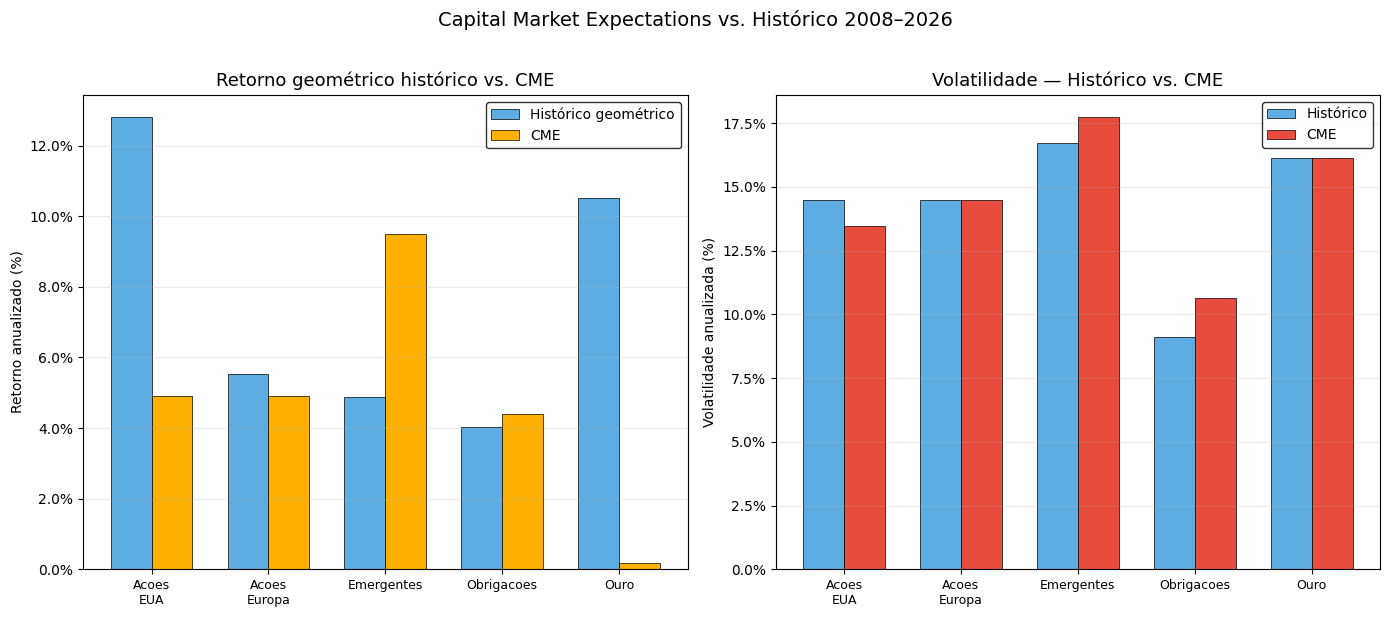

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor="white")
assets_plot = [a for a in cme_returns.index if a != "Liquidez"]
x = np.arange(len(assets_plot))
width = 0.35

ax1 = axes[0]
ax1.set_facecolor("white")
ax1.bar(x - width/2, [hist_ret_geom[a]*100 for a in assets_plot], width,
        label="Histórico geométrico", color="#5dade2", edgecolor="black", linewidth=0.5)
ax1.bar(x + width/2, [cme_returns[a]*100 for a in assets_plot], width,
        label="CME", color="#ffb000", edgecolor="black", linewidth=0.5)
ax1.set_title("Retorno geométrico histórico vs. CME", color="black", fontsize=13)
ax1.set_ylabel("Retorno anualizado (%)", color="black")
ax1.set_xticks(x)
ax1.set_xticklabels([a.replace("_","\n") for a in assets_plot], color="black", fontsize=9)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.1f}%"))
ax1.grid(axis="y", alpha=0.25)
ax1.axhline(0, color="black", linewidth=0.6)
ax1.legend(facecolor="white", edgecolor="black", fontsize=10)

ax2 = axes[1]
ax2.set_facecolor("white")
ax2.bar(x - width/2, [hist_vol[a]*100 for a in assets_plot], width,
        label="Histórico", color="#5dade2", edgecolor="black", linewidth=0.5)
ax2.bar(x + width/2, [cme_vol[a]*100 for a in assets_plot], width,
        label="CME", color="#e74c3c", edgecolor="black", linewidth=0.5)
ax2.set_title("Volatilidade — Histórico vs. CME", color="black", fontsize=13)
ax2.set_ylabel("Volatilidade anualizada (%)", color="black")
ax2.set_xticks(x)
ax2.set_xticklabels([a.replace("_","\n") for a in assets_plot], color="black", fontsize=9)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.1f}%"))
ax2.grid(axis="y", alpha=0.25)
ax2.legend(facecolor="white", edgecolor="black", fontsize=10)

plt.suptitle("Capital Market Expectations vs. Histórico 2008–2026",
             color="black", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## CME 9. Otimização CME por Fase

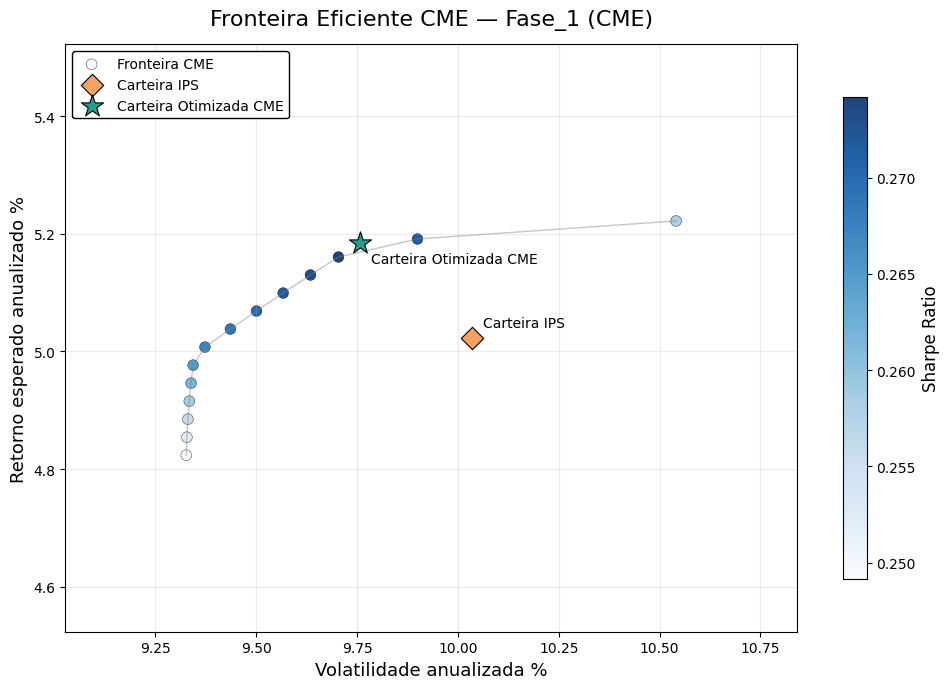

Fase_1 — CME
Pesos IPS:
Acoes_EUA       40.00%
Acoes_Europa    25.00%
Emergentes      10.00%
Obrigacoes      20.00%
Ouro             5.00%
Name: Fase_1, dtype: object

Pesos otimizados:
Acoes_EUA       40.00%
Acoes_Europa    20.00%
Emergentes      12.00%
Obrigacoes      25.00%
Ouro             3.00%
dtype: object

Resumo comparativo:
                Métrica Carteira IPS Carteira Otimizada
     Retorno anualizado        5.02%              5.18%
Volatilidade anualizada       10.03%              9.76%
                 Sharpe       25.14%             27.51%


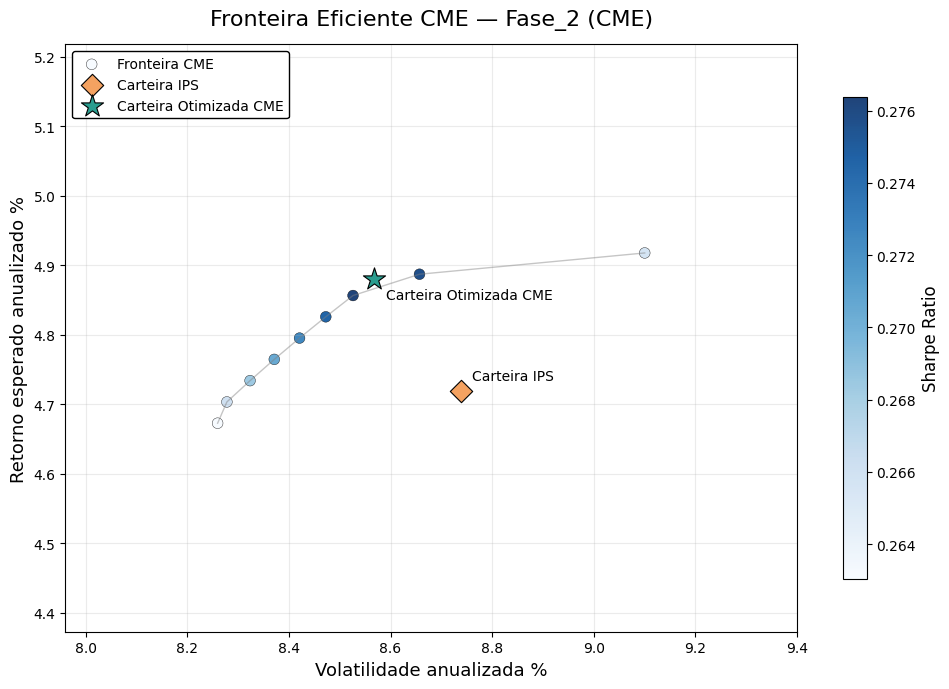

Fase_2 — CME
Pesos IPS:
Acoes_EUA       30.00%
Acoes_Europa    25.00%
Emergentes       5.00%
Obrigacoes      35.00%
Ouro             5.00%
Name: Fase_2, dtype: object

Pesos otimizados:
Acoes_EUA       30.00%
Acoes_Europa    20.00%
Emergentes       7.00%
Obrigacoes      40.00%
Ouro             3.00%
dtype: object

Resumo comparativo:
                Métrica Carteira IPS Carteira Otimizada
     Retorno anualizado        4.72%              4.88%
Volatilidade anualizada        8.74%              8.57%
                 Sharpe       25.39%             27.77%


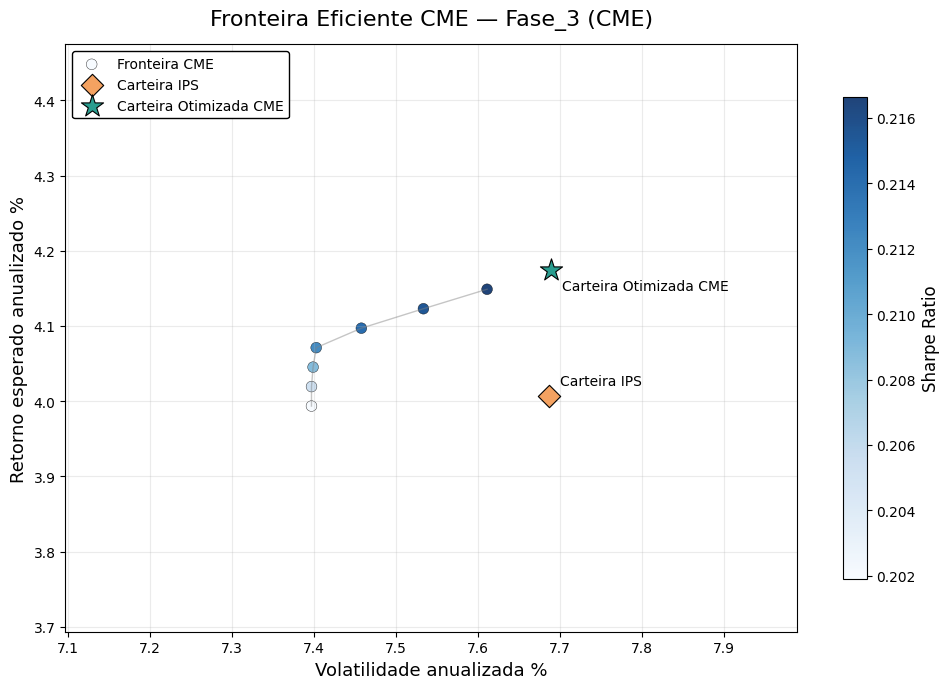

Fase_3 — CME
Pesos IPS:
Acoes_EUA       15.00%
Acoes_Europa    10.00%
Obrigacoes      60.00%
Ouro            10.00%
Liquidez         5.00%
Name: Fase_3, dtype: object

Pesos otimizados:
Acoes_EUA       20.00%
Acoes_Europa    14.00%
Obrigacoes      55.00%
Ouro             8.00%
Liquidez         3.00%
dtype: object

Resumo comparativo:
                Métrica Carteira IPS Carteira Otimizada
     Retorno anualizado        4.01%              4.17%
Volatilidade anualizada        7.69%              7.69%
                 Sharpe       19.60%             21.78%


In [28]:
RISK_FREE_RATE_CME = macro["taxa_livre_risco_longo_prazo"]

cme_results = {}
for phase in ["Fase_1", "Fase_2", "Fase_3"]:
    cme_results[phase] = analyze_frontier_for_phase(
        portfolio_name=phase,
        expected_returns=cme_returns,
        covariance_matrix=cme_cov,
        risk_free_rate=RISK_FREE_RATE_CME,
        scenario_label="CME",
        frontier_label="Fronteira CME",
        current_label="Carteira IPS",
        optimized_label="Carteira Otimizada CME",
        title_prefix="Fronteira Eficiente CME"
    )

In [29]:
quadro_6_rows = []

for phase in ["Fase_1", "Fase_2", "Fase_3"]:
    result = cme_results[phase]
    quadro_6_rows.append({
        "Carteira": phase.replace("Fase_", "Carteira "),
        "Retorno CME": result["ips_ret"],
        "Volatilidade CME": result["ips_vol"],
        "Sharpe CME": result["ips_sharpe"],
    })

quadro_6 = pd.DataFrame(quadro_6_rows)

print("Quadro 6 - Métricas CME das carteiras IPS")
print(quadro_6.to_string(index=False, formatters={
    "Retorno CME": lambda x: f"{x:.2%}",
    "Volatilidade CME": lambda x: f"{x:.2%}",
    "Sharpe CME": lambda x: f"{x:.2f}",
}))

Quadro 6 - Métricas CME das carteiras IPS
  Carteira Retorno CME Volatilidade CME Sharpe CME
Carteira 1       5.02%           10.03%       0.25
Carteira 2       4.72%            8.74%       0.25
Carteira 3       4.01%            7.69%       0.20


## CME 10. Comparação Final: Backtest vs. CME

In [30]:
print("=" * 90)
print("COMPARAÇÃO CONSOLIDADA — Carteiras Otimizadas: Backtest vs. CME")
print("=" * 90)

for phase in ["Fase_1", "Fase_2", "Fase_3"]:
    hist = historical_optimization_results[phase]
    cme  = cme_results[phase]
    active_assets = hist["active_assets"]

    print(f"\n{'─'*70}  {phase}")
    weights_compare = pd.DataFrame({
        "Peso IPS": weights[phase].reindex(active_assets).fillna(0),
        "Otimizado Backtest": hist["opt_weights"],
        "Otimizado CME": cme["opt_weights"],
    })
    print(weights_compare.applymap(lambda x: f"{x:.2%}").to_string())

    print(f"\n  {'Métrica':<30} {'Backtest':>12} {'CME':>12}")
    print(f"  {'Retorno esperado':<30} {hist['opt_ret']:>12.2%} {cme['opt_ret']:>12.2%}")
    print(f"  {'Volatilidade':<30} {hist['opt_vol']:>12.2%} {cme['opt_vol']:>12.2%}")
    print(f"  {'Sharpe Ratio':<30} {hist['opt_sharpe']:>12.2f} {cme['opt_sharpe']:>12.2f}")

print(f"\n{'='*90}")
print(f"Taxa sem risco Backtest: {RISK_FREE_RATE:.2%} | Taxa sem risco CME: {RISK_FREE_RATE_CME:.2%}")

COMPARAÇÃO CONSOLIDADA — Carteiras Otimizadas: Backtest vs. CME

──────────────────────────────────────────────────────────────────────  Fase_1
             Peso IPS Otimizado Backtest Otimizado CME
Acoes_EUA      40.00%             41.11%        40.00%
Acoes_Europa   25.00%             20.00%        20.00%
Emergentes     10.00%              8.00%        12.00%
Obrigacoes     20.00%             23.89%        25.00%
Ouro            5.00%              7.00%         3.00%

  Métrica                            Backtest          CME
  Retorno esperado                      9.03%        5.18%
  Volatilidade                          9.93%        9.76%
  Sharpe Ratio                           0.82         0.28

──────────────────────────────────────────────────────────────────────  Fase_2
             Peso IPS Otimizado Backtest Otimizado CME
Acoes_EUA      30.00%             35.00%        30.00%
Acoes_Europa   25.00%             20.00%        20.00%
Emergentes      5.00%              3.00%    

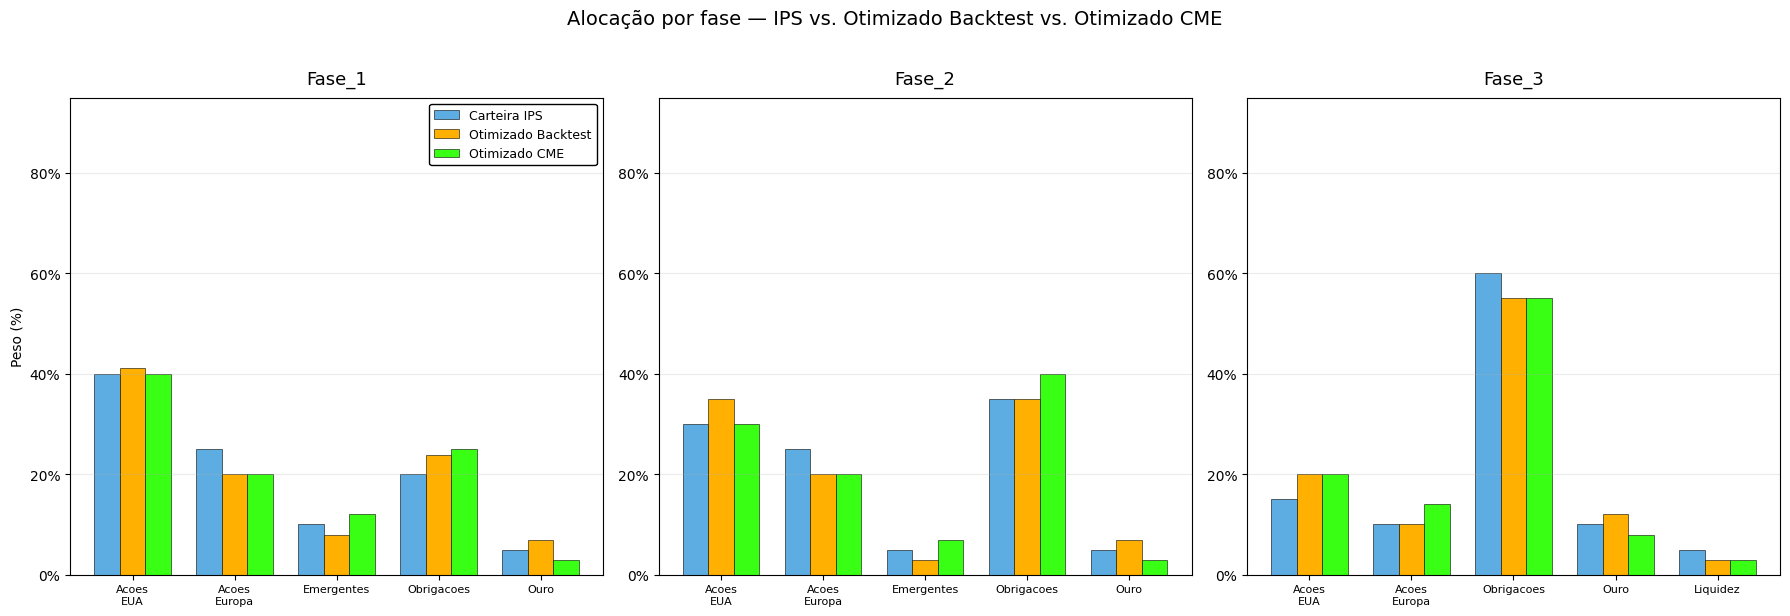

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), facecolor="white")
colors_bars = ["#5dade2", "#ffb000", "#39ff14"]
labels_bars = ["Carteira IPS", "Otimizado Backtest", "Otimizado CME"]

for idx, phase in enumerate(["Fase_1", "Fase_2", "Fase_3"]):
    ax = axes[idx]
    ax.set_facecolor("white")

    hist = historical_optimization_results[phase]
    cme  = cme_results[phase]
    active_assets = hist["active_assets"]

    ips_w = weights[phase].reindex(active_assets).fillna(0).astype(float)
    ips_w = ips_w / ips_w.sum()

    x = np.arange(len(active_assets))
    width = 0.25

    for i, (vals, color, label) in enumerate(zip(
        [ips_w.values, hist["opt_weights"].values, cme["opt_weights"].values],
        colors_bars,
        labels_bars
    )):
        ax.bar(x + (i - 1) * width, vals * 100, width, label=label,
               color=color, edgecolor="black", linewidth=0.4)

    ax.set_title(phase, color="black", fontsize=13, pad=10)
    ax.set_xticks(x)
    ax.set_xticklabels([a.replace("_", "\n") for a in active_assets], color="black", fontsize=8)
    ax.set_ylabel("Peso (%)" if idx == 0 else "", color="black")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
    ax.grid(axis="y", alpha=0.25)
    ax.set_ylim(0, 95)
    if idx == 0:
        ax.legend(facecolor="white", edgecolor="black", framealpha=1, fontsize=9, loc="upper right")
    for spine in ax.spines.values():
        spine.set_color("black")

plt.suptitle("Alocação por fase — IPS vs. Otimizado Backtest vs. Otimizado CME",
             color="black", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## Monte Carlo — Cenário histórico vs. cenário CME

Esta secção apresenta dois cenários, conforme a orientação recebida:

1. **Histórico / bootstrap** — reamostragem dos retornos mensais observados entre 2008 e 2026. Este cenário responde à pergunta: *o que aconteceria se a distribuição histórica se repetisse?*
2. **CME / prospetivo** — simulação com retornos esperados, volatilidades e correlações derivados das Capital Market Expectations. Este cenário é o mais relevante para a recomendação, porque a decisão de investimento deve estar orientada para o futuro e não apenas para o desempenho passado.

A diferença entre os resultados é interpretada como consequência natural da metodologia: o período histórico foi particularmente favorável para ações dos EUA e ouro, enquanto as CME incorporam expectativas mais conservadoras e prospetivas.


In [32]:
# ═══════════════════════════════════════════════════════════════════════════════
# Monte Carlo — Projeção da Carteira de Reforma por Fase
# Dois cenários: Histórico/Bootstrap vs. Prospetivo/CME
# ═══════════════════════════════════════════════════════════════════════════════

from scipy.linalg import cholesky

# ── 1. Parâmetros gerais ─────────────────────────────────────────────────────
N_SIMULATIONS           = 50_000
START_AGE               = 25
RETIREMENT_AGE          = 60
N_YEARS                 = RETIREMENT_AGE - START_AGE
N_MONTHS                = N_YEARS * 12
INITIAL_PORTFOLIO_VALUE = 0
MONTHLY_CONTRIBUTION_P1 = 100     # €/mês dos 25 aos 30 anos
MONTHLY_CONTRIBUTION_P2 = 300     # €/mês a partir dos 30 anos (base)
CONTRIBUTION_GROWTH     = 0.025   # crescimento anual das contribuições
EXPECTED_INFLATION      = 0.02    # deflator para valores reais
REBALANCE_FREQ_MONTHS   = 12      # rebalanceamento anual
NU                      = 5       # graus de liberdade t-Student para o cenário CME
RANDOM_SEED             = 42

rng = np.random.default_rng(RANDOM_SEED)

assets_mc = ["Acoes_EUA", "Acoes_Europa", "Emergentes", "Obrigacoes", "Ouro", "Liquidez"]

# ── 2. Funções auxiliares ────────────────────────────────────────────────────
def get_phase(month):
    """Define a fase da IPS em função da idade do investidor."""
    age = START_AGE + month / 12
    if age < 35:
        return "Fase_1"
    elif age < 50:
        return "Fase_2"
    else:
        return "Fase_3"


def get_monthly_contribution(month):
    """Contribuição mensal: 100€ até aos 30 anos; 300€ depois, com crescimento anual."""
    age = START_AGE + month / 12
    if age < 30:
        return MONTHLY_CONTRIBUTION_P1
    years_since_30 = int(age - 30)
    return MONTHLY_CONTRIBUTION_P2 * ((1 + CONTRIBUTION_GROWTH) ** years_since_30)


def get_target_weights(phase):
    """Pesos-alvo da IPS para a fase correspondente."""
    w = weights[phase].reindex(assets_mc).fillna(0).astype(float)
    if not np.isclose(w.sum(), 1.0):
        w = w / w.sum()
    return w.values


def simulate_portfolio(monthly_returns_cube, scenario_label):
    """
    Simula a evolução da carteira com contribuições mensais, transição de fases
    e rebalanceamento anual.

    monthly_returns_cube: array com shape (N_SIMULATIONS, N_MONTHS, N_ASSETS)
    """
    portfolio_values = np.zeros((N_SIMULATIONS, N_MONTHS + 1))
    portfolio_values[:, 0] = INITIAL_PORTFOLIO_VALUE

    current_w = np.tile(phase_weights[0], (N_SIMULATIONS, 1))

    for month in range(N_MONTHS):
        if month % REBALANCE_FREQ_MONTHS == 0:
            current_w = np.tile(phase_weights[month], (N_SIMULATIONS, 1))

        # contribuição aplicada no início de cada mês
        portfolio_values[:, month] += contributions[month]

        monthly_ret = (monthly_returns_cube[:, month, :] * current_w).sum(axis=1)

        portfolio_values[:, month + 1] = np.maximum(
            portfolio_values[:, month] * (1 + monthly_ret),
            0
        )

    print(f"Simulação concluída — {scenario_label}.")
    return portfolio_values


def summarize_mc(portfolio_values, scenario_label, targets_real=None):
    """Produz quadros de resultados e sensibilidade para um cenário Monte Carlo."""
    if targets_real is None:
        targets_real = [100_000, 120_000, 150_000, 170_000, 180_000, 200_000, 250_000]

    # Garantir que os objetivos são numéricos
    targets_real = np.array(targets_real, dtype=float)

    final_values = portfolio_values[:, -1]
    inflation_factor = (1 + EXPECTED_INFLATION) ** N_YEARS
    final_values_real = final_values / inflation_factor

    pcts_nom = [5, 25, 50, 75, 95]
    pcts_real = [5, 50, 95]

    results_df = pd.DataFrame({
        "Cenario": scenario_label,
        "Indicador": (
            [f"P{p} nominal" for p in pcts_nom] +
            ["Média nominal"] +
            [f"P{p} real" for p in pcts_real] +
            ["Média real"]
        ),
        "Valor": (
            [np.percentile(final_values, p) for p in pcts_nom] +
            [np.mean(final_values)] +
            [np.percentile(final_values_real, p) for p in pcts_real] +
            [np.mean(final_values_real)]
        )
    })
    results_df["Valor"] = results_df["Valor"].round(2)

    sensitivity_df = pd.DataFrame({
        "Cenario": scenario_label,
        "Objetivo real": targets_real,
        "Probabilidade": [(final_values_real >= t).mean() for t in targets_real]
    })

    indicators_df = pd.DataFrame({
        "Cenario": [scenario_label],
        "Total contribuido": [total_contributions],
        "Mediana nominal": [np.percentile(final_values, 50)],
        "Mediana real": [np.percentile(final_values_real, 50)],
        "Media nominal": [np.mean(final_values)],
        "Media real": [np.mean(final_values_real)],
        "Ganho mediano vs contribuicoes": [np.percentile(final_values, 50) - total_contributions]
    })

    return results_df, sensitivity_df, indicators_df, final_values, final_values_real

# ── 3. Vetores determinísticos por mês ───────────────────────────────────────
phases_by_month = [get_phase(m) for m in range(N_MONTHS)]
contributions   = np.array([get_monthly_contribution(m) for m in range(N_MONTHS)])
phase_weights   = np.array([get_target_weights(p) for p in phases_by_month])
total_contributions = contributions.sum()

print("Parâmetros base da simulação:")
print(f"  Simulações:                 {N_SIMULATIONS:,}")
print(f"  Horizonte:                  {N_YEARS} anos / {N_MONTHS} meses")
print(f"  Total contribuído:           {total_contributions:,.2f} €")
print(f"  Inflação esperada anual:     {EXPECTED_INFLATION:.2%}")
print(f"  Taxa livre de risco CME:      {macro['taxa_livre_risco_longo_prazo']:.2%} "
      f"(inflação {macro['inflacao']:.2%} + r* {macro['taxa_real_neutra']:.2%})")
print(f"  Rebalanceamento:             anual")

Parâmetros base da simulação:
  Simulações:                 50,000
  Horizonte:                  35 anos / 420 meses
  Total contribuído:           164,049.73 €
  Inflação esperada anual:     2.00%
  Taxa livre de risco CME:      2.50% (inflação 2.00% + r* 0.50%)
  Rebalanceamento:             anual


In [33]:
# ═══════════════════════════════════════════════════════════════════════════════
# CENÁRIO A — HISTÓRICO / BOOTSTRAP
# ═══════════════════════════════════════════════════════════════════════════════
# Usa diretamente os retornos mensais observados entre 2008 e 2026.
# O bootstrap preserva combinações históricas de retornos entre ativos, porque cada draw corresponde a uma linha mensal completa do dataset histórico.
# Reamostragem de blocos contíguos de 12 meses para preservar parcialmente a estrutura temporal dos retornos: momentum, reversão e sequências de crise/recuperação.

hist_monthly_returns = asset_returns[assets_mc].dropna().copy()
hist_matrix = hist_monthly_returns.values.astype(float)

BLOCK_SIZE = 12
n_hist_months = len(hist_matrix)
n_blocks_needed = int(np.ceil(N_MONTHS / BLOCK_SIZE))

monthly_returns_historico = np.zeros((N_SIMULATIONS, N_MONTHS, len(assets_mc)))

for sim in range(N_SIMULATIONS):
    simulated_path = []

    for _ in range(n_blocks_needed):
        start_idx = rng.integers(0, n_hist_months - BLOCK_SIZE + 1)
        block = hist_matrix[start_idx:start_idx + BLOCK_SIZE]
        simulated_path.append(block)

    simulated_path = np.vstack(simulated_path)[:N_MONTHS]
    monthly_returns_historico[sim, :, :] = simulated_path

portfolio_values_historico = simulate_portfolio(
    monthly_returns_cube=monthly_returns_historico,
    scenario_label="Histórico / block bootstrap"
)

Simulação concluída — Histórico / block bootstrap.


In [34]:
# ═══════════════════════════════════════════════════════════════════════════════
# CENÁRIO B — PROSPETIVO / CME
# ═══════════════════════════════════════════════════════════════════════════════
# Usa retornos esperados CME, volatilidades/correlações esperadas e distribuição
# t-Student multivariada para refletir fat tails. Este é o cenário principal para
# decisão prospetiva, porque olha para expectativas futuras em vez de repetir a
# amostra histórica.

# Usa cme_ouro_por_fase calculado na secção CME 5, evitando duplicação de pressupostos.
cme_returns_por_fase = {
    "Fase_1": cme_returns[assets_mc].copy(),
    "Fase_2": cme_returns[assets_mc].copy(),
    "Fase_3": cme_returns[assets_mc].copy(),
}

# Ações: rerating P/E apenas na Fase 1
cme_returns_por_fase["Fase_1"]["Acoes_EUA"] = cme_acoes_eua_f1
cme_returns_por_fase["Fase_1"]["Acoes_Europa"] = cme_acoes_europa_f1

cme_returns_por_fase["Fase_2"]["Acoes_EUA"] = cme_acoes_eua_f2f3
cme_returns_por_fase["Fase_2"]["Acoes_Europa"] = cme_acoes_europa_f2f3

cme_returns_por_fase["Fase_3"]["Acoes_EUA"] = cme_acoes_eua_f2f3
cme_returns_por_fase["Fase_3"]["Acoes_Europa"] = cme_acoes_europa_f2f3

# Ouro: mean reversion por fase
cme_returns_por_fase["Fase_2"]["Ouro"] = cme_ouro_por_fase["Fase_2"]
cme_returns_por_fase["Fase_3"]["Ouro"] = cme_ouro_por_fase["Fase_3"]


print("\nCME anuais por fase usados no Monte Carlo:")
print(f"  {'Ativo':<20} {'Fase 1':>10} {'Fase 2':>10} {'Fase 3':>10}")
print(f"  {'-'*54}")
for ativo in assets_mc:
    print(
        f"  {ativo:<20} "
        f"{cme_returns_por_fase['Fase_1'][ativo]:>10.2%} "
        f"{cme_returns_por_fase['Fase_2'][ativo]:>10.2%} "
        f"{cme_returns_por_fase['Fase_3'][ativo]:>10.2%}"
    )

# Conversão anual → mensal: retorno composto equivalente.
cme_monthly_por_fase = {
    fase: ((1 + cme_returns_por_fase[fase]) ** (1 / 12) - 1).values
    for fase in ["Fase_1", "Fase_2", "Fase_3"]
}
mu_monthly_cme = np.array([cme_monthly_por_fase[p] for p in phases_by_month])

# Covariância mensal CME e t-Student com fat tails.
cme_monthly_cov = cme_cov.loc[assets_mc, assets_mc].astype(float) / 12
cov_matrix_mc = cme_monthly_cov.values
chol_L = cholesky(cov_matrix_mc, lower=True)

n_assets = len(assets_mc)
n_draws = N_MONTHS * N_SIMULATIONS

print(f"\nA gerar {N_SIMULATIONS:,} × {N_MONTHS} draws t-Student CME (ν={NU})...")
Z = rng.standard_normal((n_assets, n_draws))
chi2 = rng.chisquare(df=NU, size=n_draws)
# Escala sqrt((ν-2)/ν) para que a matriz de covariância simulada fique alinhada
# com a covariância CME definida, mantendo caudas mais pesadas do que a normal.
X = (chol_L @ Z) / np.sqrt(chi2 / NU) * np.sqrt((NU - 2) / NU)
shocks_cme = X.T.reshape(N_SIMULATIONS, N_MONTHS, n_assets)
monthly_returns_cme = shocks_cme + mu_monthly_cme[np.newaxis, :, :]

portfolio_values_cme = simulate_portfolio(
    monthly_returns_cube=monthly_returns_cme,
    scenario_label="CME / prospetivo"
)


CME anuais por fase usados no Monte Carlo:
  Ativo                    Fase 1     Fase 2     Fase 3
  ------------------------------------------------------
  Acoes_EUA                 4.89%      6.35%      6.35%
  Acoes_Europa              4.91%      6.35%      6.35%
  Emergentes                9.50%      9.50%      9.50%
  Obrigacoes                4.40%      4.40%      4.40%
  Ouro                      0.16%      0.98%      1.49%
  Liquidez                  2.50%      2.50%      2.50%

A gerar 50,000 × 420 draws t-Student CME (ν=5)...
Simulação concluída — CME / prospetivo.


In [35]:
# ═══════════════════════════════════════════════════════════════════════════════
# RESULTADOS COMPARATIVOS
# ═══════════════════════════════════════════════════════════════════════════════
results_mc_historico, sensitivity_mc_historico, indicadores_mc_historico, _, final_values_real_historico = summarize_mc(
    portfolio_values_historico,
    scenario_label="Histórico / bootstrap"
)

results_mc_cme, sensitivity_mc_cme, indicadores_mc_cme, _, final_values_real_cme = summarize_mc(
    portfolio_values_cme,
    scenario_label="CME / prospetivo"
)

results_mc = pd.concat([results_mc_historico, results_mc_cme], ignore_index=True)
sensitivity_mc = pd.concat([sensitivity_mc_historico, sensitivity_mc_cme], ignore_index=True)
indicadores_mc = pd.concat([indicadores_mc_historico, indicadores_mc_cme], ignore_index=True)


comparacao_mc = indicadores_mc.copy()
comparacao_mc["Diferença vs Histórico - Mediana real"] = np.nan
hist_mediana_real = comparacao_mc.loc[comparacao_mc["Cenario"] == "Histórico / bootstrap", "Mediana real"].iloc[0]
comparacao_mc.loc[comparacao_mc["Cenario"] == "CME / prospetivo", "Diferença vs Histórico - Mediana real"] = (
    comparacao_mc.loc[comparacao_mc["Cenario"] == "CME / prospetivo", "Mediana real"] - hist_mediana_real
)

print("\n" + "=" * 88)
print("MONTE CARLO — COMPARAÇÃO DOS CENÁRIOS")
print("=" * 88)
print(results_mc.to_string(index=False, formatters={"Valor": lambda x: f"{x:,.2f} €"}))

print("\nIndicadores de acumulação:")
print(indicadores_mc.to_string(index=False, formatters={
    "Total contribuido": lambda x: f"{x:,.2f} €",
    "Mediana nominal": lambda x: f"{x:,.2f} €",
    "Mediana real": lambda x: f"{x:,.2f} €",
    "Media nominal": lambda x: f"{x:,.2f} €",
    "Media real": lambda x: f"{x:,.2f} €",
    "Ganho mediano vs contribuicoes": lambda x: f"{x:,.2f} €",
}))

print("\nSensibilidade a objetivos reais:")
print(sensitivity_mc.to_string(index=False, formatters={
    "Objetivo real": lambda x: f"{x:,.0f} €",
    "Probabilidade": lambda x: f"{x:.2%}",
}))

print("\nLeitura metodológica para o relatório:")
print("  • Histórico/bootstrap: mostra o que aconteceria se a distribuição 2008–2026 se repetisse.")
print("  • CME/prospetivo: cenário principal de decisão, porque incorpora expectativas futuras.")
print("  • A diferença entre cenários é esperada: 2008–2026 foi particularmente favorável para ações dos EUA e ouro.")


MONTE CARLO — COMPARAÇÃO DOS CENÁRIOS
              Cenario     Indicador        Valor
Histórico / bootstrap    P5 nominal 364,672.11 €
Histórico / bootstrap   P25 nominal 480,824.33 €
Histórico / bootstrap   P50 nominal 588,239.10 €
Histórico / bootstrap   P75 nominal 726,757.95 €
Histórico / bootstrap   P95 nominal 995,356.18 €
Histórico / bootstrap Média nominal 622,652.76 €
Histórico / bootstrap       P5 real 182,346.12 €
Histórico / bootstrap      P50 real 294,135.79 €
Histórico / bootstrap      P95 real 497,705.57 €
Histórico / bootstrap    Média real 311,343.57 €
     CME / prospetivo    P5 nominal 216,692.51 €
     CME / prospetivo   P25 nominal 281,971.57 €
     CME / prospetivo   P50 nominal 341,430.16 €
     CME / prospetivo   P75 nominal 416,203.46 €
     CME / prospetivo   P95 nominal 558,595.14 €
     CME / prospetivo Média nominal 358,951.30 €
     CME / prospetivo       P5 real 108,352.24 €
     CME / prospetivo      P50 real 170,724.51 €
     CME / prospetivo      P95

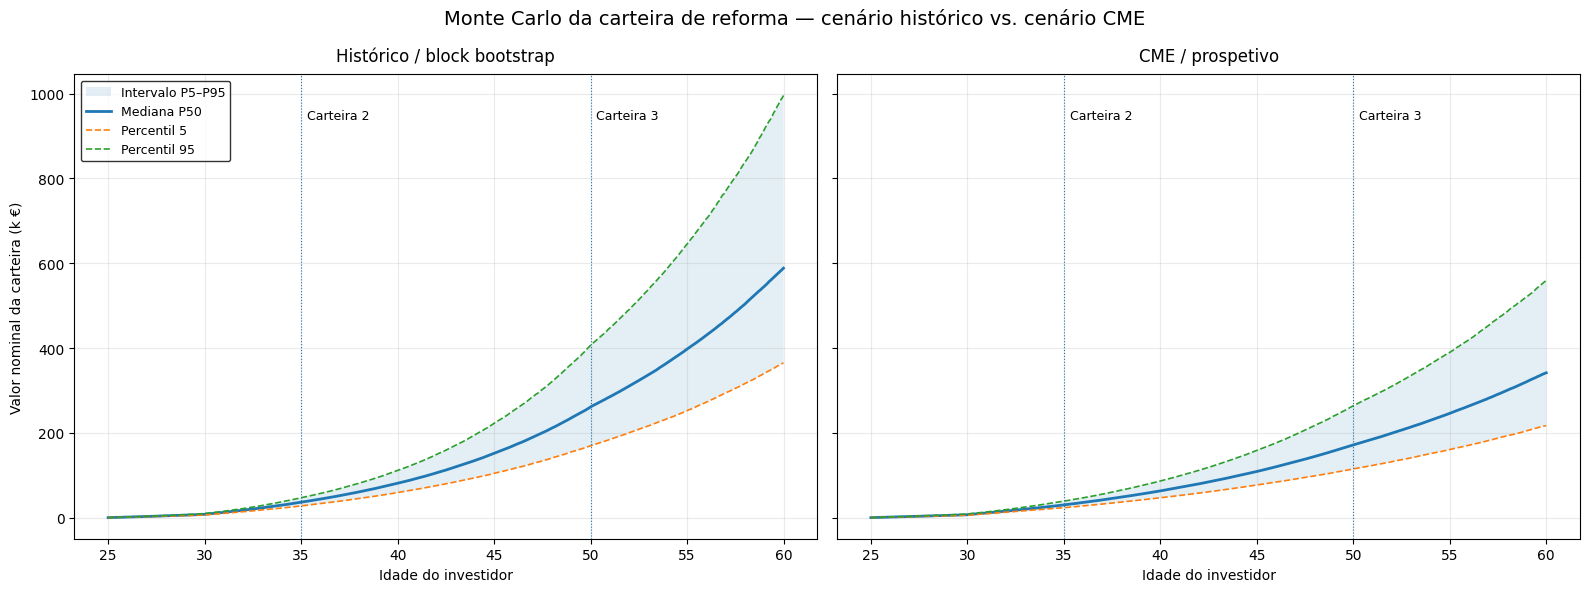

In [36]:
# ── Gráfico 1 — Evolução P5/P50/P95 por cenário ──────────────────────────────
ages = np.arange(N_MONTHS + 1) / 12 + START_AGE
paths = {
    "Histórico / block bootstrap": portfolio_values_historico,
    "CME / prospetivo": portfolio_values_cme,
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor="white", sharey=True)
for ax, (scenario_label, values) in zip(axes, paths.items()):
    p5_path = np.percentile(values, 5, axis=0)
    p50_path = np.percentile(values, 50, axis=0)
    p95_path = np.percentile(values, 95, axis=0)

    ax.set_facecolor("white")
    ax.fill_between(ages, p5_path / 1e3, p95_path / 1e3, alpha=0.12, label="Intervalo P5–P95")
    ax.plot(ages, p50_path / 1e3, linewidth=2.0, label="Mediana P50")
    ax.plot(ages, p5_path / 1e3, linewidth=1.2, linestyle="--", label="Percentil 5")
    ax.plot(ages, p95_path / 1e3, linewidth=1.2, linestyle="--", label="Percentil 95")

    for age_t, lbl_t in [(35, "Carteira 2"), (50, "Carteira 3")]:
        ax.axvline(age_t, linewidth=0.8, linestyle=":")
        ax.text(age_t + 0.3, ax.get_ylim()[1] * 0.90, lbl_t, fontsize=9)

    ax.set_title(scenario_label, fontsize=12, pad=10)
    ax.set_xlabel("Idade do investidor")
    ax.grid(True, alpha=0.25)

axes[0].set_ylabel("Valor nominal da carteira (k €)")
axes[0].legend(facecolor="white", edgecolor="black", fontsize=9, loc="upper left")
fig.suptitle("Monte Carlo da carteira de reforma — cenário histórico vs. cenário CME", fontsize=14)
plt.tight_layout()
plt.show()

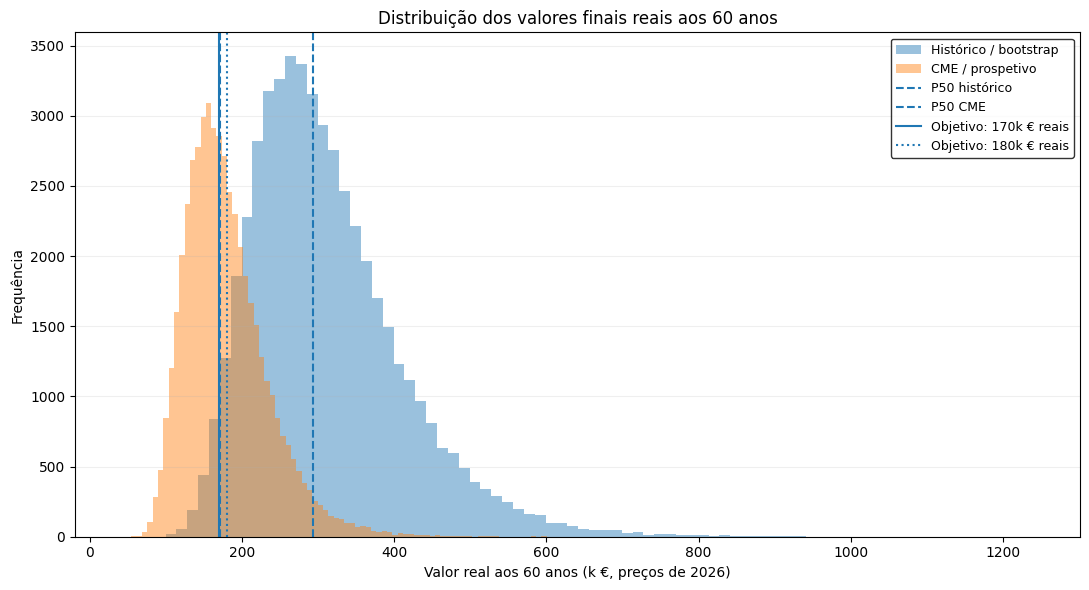

In [37]:
# ── Gráfico 2 — Distribuição dos valores finais reais ────────────────────────
fig, ax = plt.subplots(figsize=(11, 6), facecolor="white")
ax.set_facecolor("white")

ax.hist(final_values_real_historico / 1e3, bins=80, alpha=0.45, label="Histórico / bootstrap")
ax.hist(final_values_real_cme / 1e3, bins=80, alpha=0.45, label="CME / prospetivo")

for values_real, label in [
    (final_values_real_historico, "P50 histórico"),
    (final_values_real_cme, "P50 CME"),
]:
    ax.axvline(np.percentile(values_real, 50) / 1e3, linestyle="--", linewidth=1.5, label=label)

ax.axvline(170, linewidth=1.5, linestyle="-", label="Objetivo: 170k € reais")
ax.axvline(180, linewidth=1.5, linestyle=":", label="Objetivo: 180k € reais")

ax.set_title("Distribuição dos valores finais reais aos 60 anos")
ax.set_xlabel("Valor real aos 60 anos (k €, preços de 2026)")
ax.set_ylabel("Frequência")
ax.legend(facecolor="white", edgecolor="black", fontsize=9)
ax.grid(True, alpha=0.2, axis="y")
plt.tight_layout()
plt.show()

In [38]:
# ── Quadro-resumo compacto para inserir no relatório ─────────────────────────
quadro_mc_relatorio = indicadores_mc[[
    "Cenario",
    "Total contribuido",
    "Mediana nominal",
    "Mediana real",
    "Ganho mediano vs contribuicoes"
]].copy()

print("\nQuadro — Síntese Monte Carlo para o relatório")
print(quadro_mc_relatorio.to_string(index=False, formatters={
    "Total contribuido": lambda x: f"{x:,.0f} €",
    "Mediana nominal": lambda x: f"{x:,.0f} €",
    "Mediana real": lambda x: f"{x:,.0f} €",
    "Ganho mediano vs contribuicoes": lambda x: f"{x:,.0f} €",
}))



Quadro — Síntese Monte Carlo para o relatório
              Cenario Total contribuido Mediana nominal Mediana real Ganho mediano vs contribuicoes
Histórico / bootstrap         164,050 €       588,239 €    294,136 €                      424,189 €
     CME / prospetivo         164,050 €       341,430 €    170,725 €                      177,380 €


In [39]:
# ── Análise de risco de sequência: percentis por idade ───────────────────────

idades_analise = [35, 50, 60]
meses_analise = [(idade - START_AGE) * 12 for idade in idades_analise]

sequence_rows = []

for scenario_name, values in paths.items():
    for idade, mes in zip(idades_analise, meses_analise):
        valores_idade = values[:, mes]
        valores_idade_reais = valores_idade / ((1 + EXPECTED_INFLATION) ** (idade - START_AGE))

        sequence_rows.append({
            "Idade": idade,
            "P5 nominal": np.percentile(valores_idade, 5),
            "P50 nominal": np.percentile(valores_idade, 50),
            "P95 nominal": np.percentile(valores_idade, 95),
            "P5 real": np.percentile(valores_idade_reais, 5),
            "P50 real": np.percentile(valores_idade_reais, 50),
            "P95 real": np.percentile(valores_idade_reais, 95),
        })

sequence_risk_table = pd.DataFrame(sequence_rows)

print("\nAnálise de risco de sequência — percentis por idade")
print(sequence_risk_table.to_string(index=False, formatters={
    "P5 nominal": lambda x: f"{x:,.0f} €",
    "P50 nominal": lambda x: f"{x:,.0f} €",
    "P95 nominal": lambda x: f"{x:,.0f} €",
    "P5 real": lambda x: f"{x:,.0f} €",
    "P50 real": lambda x: f"{x:,.0f} €",
    "P95 real": lambda x: f"{x:,.0f} €",
}))


Análise de risco de sequência — percentis por idade
 Idade P5 nominal P50 nominal P95 nominal   P5 real  P50 real  P95 real
    35   27,794 €    36,567 €    46,988 €  22,801 €  29,998 €  38,547 €
    50  169,317 €   261,195 €   406,435 € 103,204 € 159,206 € 247,735 €
    60  364,672 €   588,239 €   995,356 € 182,346 € 294,136 € 497,706 €
    35   23,348 €    30,058 €    38,950 €  19,154 €  24,658 €  31,952 €
    50  114,979 €   171,490 €   263,771 €  70,083 € 104,529 € 160,776 €
    60  216,693 €   341,430 €   558,595 € 108,352 € 170,725 € 279,313 €
